# Test of Bayesian Markov-Chain Monte-Carlo Method with ARCS Data

This data was supplied by Garrett Granroth from the SNS / Oak Ridge National Laboratory.

The data reduction was done in Mantid, preserving events, and the events are imported from a nexus autoreduced file.  
As such, the events do have some histogram artefacts from the way that the weights are computed.
I'm not sure if this can be entirely avoided with pixelated detectors, but in an ideal world we'd compute the event weighting factors without using histograms at all.

Loading ESS event mode toolkit (emtk)
Loading curves
Loading omega functions
Loading EventModeAnalyser
/Users/phillipbentley/Code/python/mle/data/SNS/ARCS/ZrH2/IPTS-27751/nexus/201616-exported.nxs
EMAnalyser object created with 5603322 weighted events in range -199.96371 - 600.00006
Calculating KDE
Using pmb method
   - linear scale
nx 200
slice size 3.979919129936256


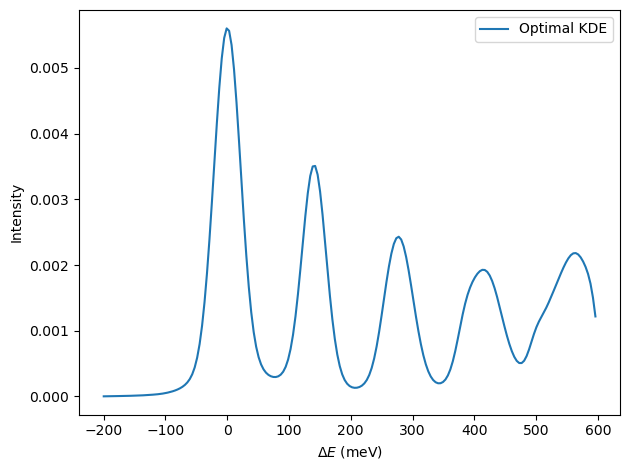

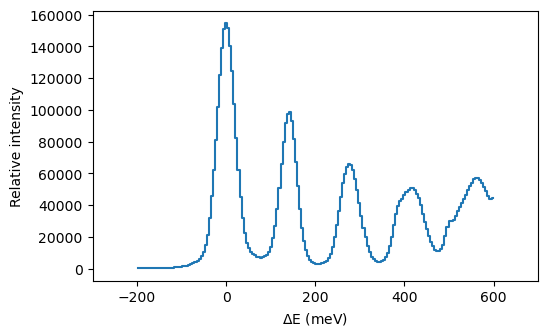

In [1]:
import h5py
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

#import warnings
#warnings.filterwarnings("error")

# Uncomment the following to make random things reproducable
# (useful for paper figures etc)
# In theory this should work, but for some reason the later analyses are shifting around

RANDOM_SEED = 0
np.random.seed(seed=RANDOM_SEED)

import lmfit 

from scipy.stats import cauchy
from scipy.stats import norm
from scipy.stats import uniform

import copy


import emtk.EventModeAnalyser.EMAnalyser as ema

# During development, importlib lets us change the source and force reload of the emtk package.
# However, whilst the error reporting line number is right, the printout of
# the offending source code is stuck to the first import.  Just so you know...
import importlib
importlib.reload(ema) 

def loadRawARCS(number):
    ldpath="/Users/phillipbentley/Code/python/mle/data/SNS/ARCS/ZrH2/IPTS-27751/nexus"
    stem="/ARCS_"
    tail=".nxs.h5"

    filename = ldpath + stem + str(number) + tail

    print(filename)

    f = h5py.File(filename, 'r')

    print( list(f.keys()) )

    entr = f['entry']
    b30 = entr['bank30_events']

    
    print( b30 )
    print( list(b30.keys()) )

    print(b30['event_id'])

    f.close()


def listkeys(obj):
    print( list( obj.keys()) )

def loadARCSmd(number):
    ldpath="/Users/phillipbentley/Code/python/mle/data/SNS/ARCS/ZrH2/IPTS-27751/nexus/"
    tail="-exported.nxs"

    filename = ldpath + str(number) + tail

    print(filename)

    f = h5py.File(filename, 'r')
    ws = f['MDEventWorkspace']
    cs = ws['coordinate_system']
    ed = ws['event_data']['event_data']
    bs = ws['box_structure']
    ex = ws['experiment0']
    pr = ws['process']
    vn = ws['visual_normalization']

    #for i in range(7):
    #    ed1 = ed[:,i]
    #    fig,ax = plt.subplots()
    #    plt.plot(ed1)

    dE = ed[:,6]
    wt = ed[:,0]

    #fig,ax = plt.subplots()
    #plt.plot(dE, wt)

    # Filter out zeros

    mask = wt > 0.0

    keepdE = dE[mask]
    keepwt = wt[mask]

    return keepdE, keepwt







""" We might need an integral function between two points (xmin, xmax) 
for every term in the fitting function, so that the relative likelihoods are 
normalised within the data bounds.  It will be good to check whether these
are actually needed or not in the final analysis, but in previous work
these proved to be necessary.
"""

def cauchy_integral(x1, x2, kappa):
    # Returns the integral of a cauchy distribution between two x values

    if x1 < x2:
        xmin = x1
        xmax = x2
    else:
        xmin = x2
        xmax = x1

    
    t1 = np.arctan(xmax/kappa)
    t2 = np.arctan(xmin/kappa)
    
    return (t1 - t2)/np.pi

    

def uniform_integral(x1, x2):
    # Returns the integral of a uniform distribution between two x values

    if(x1 == x2):
        return 0.0

    return np.absolute(x1-x2)



def gaussian_integral(x1, x2, mu=0.0, sigma=1.0):
    # Integral of a gaussian curve between two points
    t1 = norm.cdf(x1, loc=mu, scale=sigma)
    t2 = norm.cdf(x2, loc=mu, scale=sigma)
    intg = t1 - t2

    return np.absolute(intg)




evs, wts = loadARCSmd(201616)

ema1 = ema.EMAnalyser(evs, wts)

# We need a full data KDE for later...
ema1.plot_kde(log=False, loglog=False, xlabel='$\Delta E$ (meV)', method="pmb")

#ema1.plot_histogram(loglog=False, log=False, xlabel='meV')

# Manually replot and save histo figure for a paper
bn=ema1.optimal_n_bins()
hst = np.histogram(ema1.data, bins=bn, weights=ema1.weights)
hx=hst[1]
hy=hst[0]
# wipe over zero value artefacts
zind = np.where(hy==0.0)
for i in range(0, hx.size):
    if i > 0 and np.isin(i, zind):
        hy[i] = hy[i-1]
hx = hx[:-1]

#Thomas's shift is now in EMTK
hx = hx + 0.5 * (hx[1] - hx[0])

fig,ax=plt.subplots()
ax.step(hx, hy, where='mid')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.xlim(-300,700)
plt.savefig('arcsFigs/arcs_data_histo.png', dpi=600, bbox_inches='tight')
plt.show()


Least squares model function defined.
['amplitude', 'elmu', 'mu1', 'mu2', 'mu3', 'mu4', 'mubg1', 'mubg2', 'elsigma', 's1', 's2', 's3', 's4', 'sbg1', 'sbg2', 'me', 'm1', 'm2', 'm3', 'm4', 'mbg1']
[ 1.00864307e+00 -8.32387232e-02  1.40616829e+02  2.77582910e+02
  4.11741683e+02  5.61725659e+02  6.01299308e+02  4.54310334e+01
  1.98163753e+01  1.75154869e+01  2.19182349e+01  2.84305881e+01
  4.51002397e+01  1.31428345e+02  1.06817732e+02  2.87956837e-01
  1.62319657e-01  1.39275137e-01  1.41912013e-01  1.86289365e-01
  1.68383424e-02]
[3.60755444e-03 1.13938372e-01 1.58575742e-01 2.96914798e-01
 9.18566267e-01 8.94852518e+00 1.26733230e+03 1.50063827e+01
 1.52132384e-01 2.04585883e-01 3.51235978e-01 1.11357452e+00
 9.85166397e+00 4.24585800e+02 3.01760828e+01 3.55783552e-03
 2.40178408e-03 2.77262384e-03 1.26180563e-02 9.64652672e-02
 1.06078845e-01]


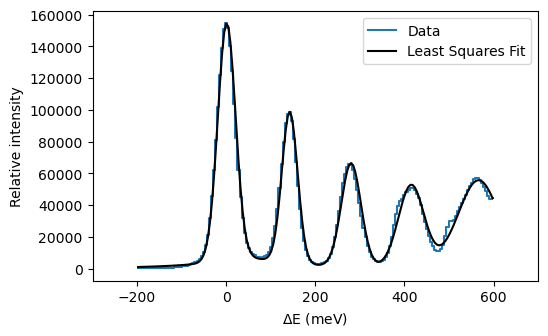

In [2]:
def big_lse_pdf(x, amplitude, elmu, mu1, mu2, mu3, mu4, mubg1, mubg2, elsigma, s1, s2, s3, s4, sbg1, sbg2, me, m1, m2, m3, m4, mbg1):
    
    mvals = ema1.simplex_weights(np.array([me, m1, m2, m3, m4, mbg1]))

    el = mvals[0] * norm.pdf(x, scale=elsigma, loc=elmu) / gaussian_integral(ema1.xmin, ema1.xmax, elsigma)

    l1 = mvals[1] * norm.pdf(x, scale=s1, loc=mu1) / gaussian_integral(ema1.xmin, ema1.xmax, mu1, s1)
    l2 = mvals[2] * norm.pdf(x, scale=s2, loc=mu2) / gaussian_integral(ema1.xmin, ema1.xmax, mu2, s2)
    l3 = mvals[3] * norm.pdf(x, scale=s3, loc=mu3) / gaussian_integral(ema1.xmin, ema1.xmax, mu3, s3)
    l4 = mvals[4] * norm.pdf(x, scale=s4, loc=mu4) / gaussian_integral(ema1.xmin, ema1.xmax, mu4, s4)
    bg1= mvals[5] * norm.pdf(x, scale=sbg1, loc=mubg1) / gaussian_integral(ema1.xmin, ema1.xmax, mubg1, sbg1)
    bg2= mvals[6] * cauchy.pdf(x, scale=sbg2, loc=mubg2) / cauchy_integral(ema1.xmin, ema1.xmax, sbg2)
    
    sol = amplitude * (el + l1 + l2 + l3 + l4 + bg1 + bg2)
    
    return sol

def big_background_pdf(x, amplitude, elmu, mu1, mu2, mu3, mu4, mubg1, mubg2, elsigma, s1, s2, s3, s4, sbg1, sbg2, me, m1, m2, m3, m4, mbg1):

    mvals = ema1.simplex_weights(np.array([me, m1, m2, m3, m4, mbg1]))

    bg1= mvals[5] * norm.pdf(x, scale=sbg1, loc=mubg1) / gaussian_integral(ema1.xmin, ema1.xmax, mubg1, sbg1)
    bg2= mvals[6] * cauchy.pdf(x, scale=sbg2, loc=mubg2) / cauchy_integral(ema1.xmin, ema1.xmax, sbg2)
    
    sol = amplitude * (bg1 + bg2)
    
    return sol


ema1.set_lse_function(big_lse_pdf)


ema1.make_lse_params(
    amplitude=dict(value=1.0, min=0.0),\
    elmu = dict(value=10.0, min=-100.0, max=100.0),\
    mu1 = dict(value=150.0, min=100.0, max=200.0),\
    mu2 = dict(value=280.0, min=200.0, max=350.0),\
    mu3 = dict(value=420.0, min=350.0, max=450.0),\
    mu4 = dict(value=560.0, min=500.0, max=620.0),\
    mubg1=dict(value=620.0, min=600.0, max=700.0),\
    mubg2=dict(value=140.0, min=0.0, max=200.0),\

    elsigma = dict(value=20.0, min=10.0, max=100.0),\
    s1 = dict(value=30.0, min=10.0, max=100.0),\
    s2 = dict(value=30.0, min=10.0, max=100.0),\
    s3 = dict(value=30.0, min=10.0, max=100.0),\
    s4 = dict(value=30.0, min=10.0, max=100.0),\
    sbg1=dict(value=100.0, min=100.0, max=250.0),\
    sbg2=dict(value=100.0, min=100.0, max=250.0),\
    me=dict(value=0.3, min=0.01, max = 1.0),\
    m1=dict(value=0.3, min=0.01, max = 1.0),\
    m2=dict(value=0.2, min=0.01, max = 1.0),\
    m3=dict(value=0.15, min=0.01, max = 1.0),\
    m4=dict(value=0.1, min=0.01, max = 1.0),\
    mbg1=dict(value=0.1, min=0.01, max=1.0)
)

lse_starting_parameters = copy.deepcopy(ema1.least_squares_parameters)


#ema1.plot_LSE_initial(loglog=False, log=False)

ema1.lse_fit()
#ema1.plot_LSE_fit(loglog=False, log=False, xlabel='meV', save="/Users/phillipbentley/Code/python/mle/arcs_lse_fit.png")

pnams = ema1.get_lse_param_names()
print(pnams)

pvals = ema1.get_lse_param_values()
print(pvals)

detailed_fit_params = pvals

psigs = ema1.get_lse_param_errors()
print(psigs)

detailed_fit_sigmas = psigs

# Manually replot and save figure for a paper
bn=ema1.optimal_n_bins()
hst = np.histogram(ema1.data, bins=bn, weights=ema1.weights)
hx=hst[1]
hy=hst[0]

# wipe over zero value artefacts
zind = np.where(hy==0.0)
for i in range(0, hx.size):
    if i > 0 and np.isin(i, zind):
        hy[i] = hy[i-1]
hx = hx[:-1]
#Thomas's shift
hx = hx + 0.5 * (hx[1] - hx[0])

fig,ax=plt.subplots()
fullhisto_x = hx
fullhisto_y = hy

ax.step(fullhisto_x, fullhisto_y, where='mid', label='Data')
nhy = hy.size
shy = np.sum(hy)
nly = ema1.lse_result.best_fit.size
sly = np.sum(ema1.lse_result.best_fit)

scl = shy * nly / (nhy * sly)

full_data_fit_line = scl*ema1.lse_result.best_fit
full_data_background_line = big_background_pdf(fullhisto_x, 
                            pvals[0],
                            pvals[1],
                            pvals[2],
                            pvals[3],
                            pvals[4],
                            pvals[5],
                            pvals[6],
                            pvals[7],
                            pvals[8],
                            pvals[9],
                            pvals[10],
                            pvals[11],
                            pvals[12],
                            pvals[13],
                            pvals[14],
                            pvals[15],
                            pvals[16],
                            pvals[17],
                            pvals[18],
                            pvals[19],
                            pvals[20])
                        
#ax.plot(ema1.histx, full_data_fit_line, color='black', label='Least Squares Fit')
ax.plot(fullhisto_x, full_data_fit_line, color='black', label='Least Squares Fit')
#ax.plot(fullhisto_x, background_line, color='black', ls=':', label='Background terms')

plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.legend()
plt.xlim(-300,700)
plt.savefig('arcsFigs/arcs_data_lse.png', dpi=600, bbox_inches='tight')
plt.show()


In [3]:
# This is needed once, because the first few points are strange
# maybe something changed during the measurement?
ema1.shuffle() 

Subsampling in order.
Calculating KDE
Using pmb method
   - linear scale
nx 200
slice size 3.9769836729438746


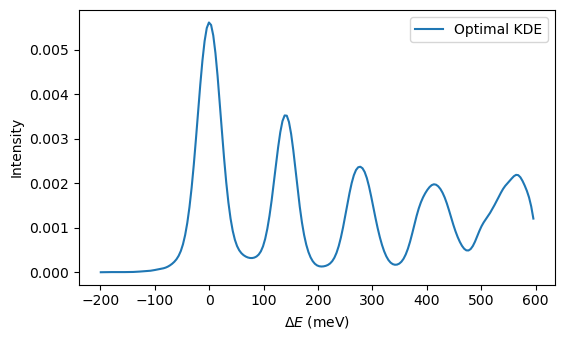

Least squares model function defined.
[ 1.05348055e+00 -3.38176066e-01  1.40610514e+02  2.77969753e+02
  4.11381628e+02  5.59869918e+02  6.99985935e+02  6.57491517e+01
  2.07263835e+01  1.86146474e+01  2.25686567e+01  2.83291610e+01
  4.60250895e+01  1.00080631e+02  1.04613090e+02  2.83679567e-01
  1.58481644e-01  1.35855699e-01  1.40030024e-01  1.36350852e-01
  7.05206979e-02]


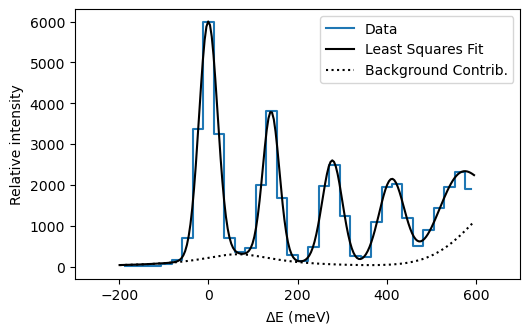

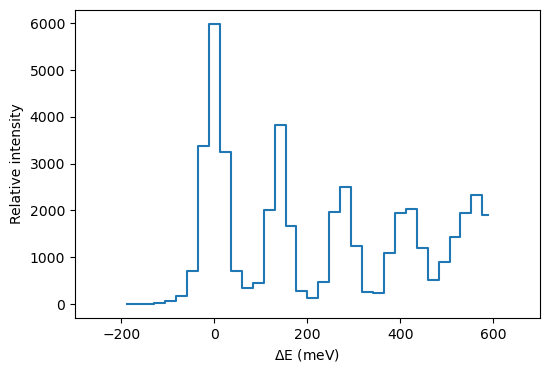

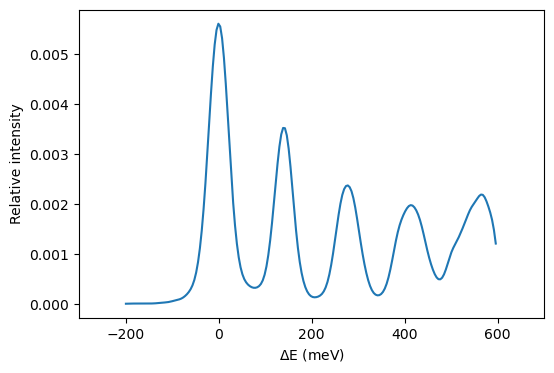

In [4]:
#cpo = ema1.subsample(150000, randomize=False)
#cpo = ema1.subsample(12000, randomize=False)
cpo = ema1.subsample(45000, randomize=False)
cpo.plot_kde(log=False, loglog=False, xlabel='$\Delta E$ (meV)', method="pmb")



cpo.set_lse_function(big_lse_pdf)

cpo.make_lse_params(
    amplitude=dict(value=1.0, min=0.0),\
    elmu = dict(value=10.0, min=-100.0, max=100.0),\
    mu1 = dict(value=150.0, min=100.0, max=200.0),\
    mu2 = dict(value=280.0, min=200.0, max=350.0),\
    mu3 = dict(value=420.0, min=350.0, max=450.0),\
    mu4 = dict(value=560.0, min=500.0, max=620.0),\
    mubg1=dict(value=620.0, min=600.0, max=700.0),\
    mubg2=dict(value=140.0, min=0.0, max=200.0),\

    elsigma = dict(value=20.0, min=10.0, max=100.0),\
    s1 = dict(value=30.0, min=10.0, max=100.0),\
    s2 = dict(value=30.0, min=10.0, max=100.0),\
    s3 = dict(value=30.0, min=10.0, max=100.0),\
    s4 = dict(value=30.0, min=10.0, max=100.0),\
    sbg1=dict(value=100.0, min=100.0, max=250.0),\
    sbg2=dict(value=100.0, min=100.0, max=250.0),\
    me=dict(value=0.3, min=0.01, max = 1.0),\
    m1=dict(value=0.3, min=0.01, max = 1.0),\
    m2=dict(value=0.2, min=0.01, max = 1.0),\
    m3=dict(value=0.15, min=0.01, max = 1.0),\
    m4=dict(value=0.1, min=0.01, max = 1.0),\
    mbg1=dict(value=0.1, min=0.01, max=1.0)
)


cpo.lse_fit()
#ema1.plot_LSE_fit(loglog=False, log=False, xlabel='meV', save="/Users/phillipbentley/Code/python/mle/arcs_lse_fit.png")


sub_pvals = cpo.get_lse_param_values()
print(sub_pvals)

# Manually replot and save figure for a paper
bn=cpo.optimal_n_bins()
hst = np.histogram(cpo.data, bins=bn, weights=cpo.weights)
hx=hst[1]
hy=hst[0]

# wipe over zero value artefacts
zind = np.where(hy==0.0)
for i in range(0, hx.size):
    if i > 0 and np.isin(i, zind):
        hy[i] = hy[i-1]
hx = hx[:-1]
#Thomas's shift
hx = hx + 0.5 * (hx[1] - hx[0])

fig,ax=plt.subplots()

subsample_histo_x = hx
subsample_histo_y = hy



#sub_data_fit_line = scl*cpo.lse_result.best_fit
sub_data_fit_line = big_lse_pdf(cpo.kdex,
                            sub_pvals[0],
                            sub_pvals[1],
                            sub_pvals[2],
                            sub_pvals[3],
                            sub_pvals[4],
                            sub_pvals[5],
                            sub_pvals[6],
                            sub_pvals[7],
                            sub_pvals[8],
                            sub_pvals[9],
                            sub_pvals[10],
                            sub_pvals[11],
                            sub_pvals[12],
                            sub_pvals[13],
                            sub_pvals[14],
                            sub_pvals[15],
                            sub_pvals[16],
                            sub_pvals[17],
                            sub_pvals[18],
                            sub_pvals[19],
                            sub_pvals[20])

sub_data_background_line = big_background_pdf(cpo.kdex,
                            sub_pvals[0],
                            sub_pvals[1],
                            sub_pvals[2],
                            sub_pvals[3],
                            sub_pvals[4],
                            sub_pvals[5],
                            sub_pvals[6],
                            sub_pvals[7],
                            sub_pvals[8],
                            sub_pvals[9],
                            sub_pvals[10],
                            sub_pvals[11],
                            sub_pvals[12],
                            sub_pvals[13],
                            sub_pvals[14],
                            sub_pvals[15],
                            sub_pvals[16],
                            sub_pvals[17],
                            sub_pvals[18],
                            sub_pvals[19],
                            sub_pvals[20])



ax.step(subsample_histo_x, subsample_histo_y, where='mid', label='Data')
nhy = hy.size
shy = np.sum(hy)
nly = sub_data_fit_line.size
sly = np.sum(sub_data_fit_line)

scl = shy * nly / (nhy * sly)

sub_data_fit_line = sub_data_fit_line * scl
sub_data_background_line = sub_data_background_line * scl

#ax.plot(ema1.histx, full_data_fit_line, color='black', label='Least Squares Fit')
ax.plot(cpo.kdex, sub_data_fit_line, color='black', label='Least Squares Fit')
ax.plot(cpo.kdex, sub_data_background_line, color='black', ls=':', label='Background Contrib.')

plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.legend()
plt.xlim(-300,700)
plt.savefig('arcsFigs/arcs_data_subsampled_lse.png', dpi=600, bbox_inches='tight')
plt.show()
















#cpo.plot_histogram(loglog=False,log=False, xlabel='meV')
#cpo.plot_kde(loglog=False,log=False, xlabel='meV', method='fdr')

# Manually replot and save figure for a paper
#bn=cpo.optimal_n_bins()
#hst = np.histogram(cpo.data, bins=bn, weights=cpo.weights)
#hx=hst[1]
#hy=hst[0]
#subsample_histo_x = hx
#subsample_histo_y = hy



fig,ax=plt.subplots()
ax.step(hx, hy, where='mid')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
fig.set_size_inches(6,4)
plt.xlim(-300,700)
plt.savefig('arcsFigs/arcs_data_subsampled_histo.png', dpi=600, bbox_inches='tight')
plt.show()

fig,ax=plt.subplots()
plt.plot(cpo.kdex, cpo.kdey)
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
fig.set_size_inches(6,4)
plt.xlim(-300,700)
plt.savefig('arcsFigs/arcs_data_subsampled_kde.png', dpi=600, bbox_inches='tight')
plt.show()

In [5]:
# Build MCMC Models with API

def simplex_weights(Qraw: np.ndarray) -> np.ndarray:
    # Raw Q values can run between 0-1 to keep things simple
    # The sum is assumed to be 1, preventing out of gamut values
    # That condition is enforced already in the last 4 terms of 
    # the log_prior above.
    # Note that Qraw has one dimension fewer
    # than the number of parameters, like this:
    # https://en.m.wikipedia.org/wiki/Ternary_plot
    
    Qraw = np.asarray(Qraw)
    
    Qsum = np.sum(Qraw)    
    Qlast = 1.0 - Qsum
    
    Qvals = np.append(Qraw, Qlast)
    return Qvals

def log_prior_function(theta):
    # The main role of this function is to set 
    # parameter bounds of the bayesian search space
    elmu, mu1, mu2, mu3, mu4, mubg1, mubg2, elsigma, s1, s2, s3, s4, sbg1, sbg2, me, m1, m2, m3, m4, mbg1 = theta
    
    if -100.0 < elmu < 100.0 and \
        100.0 < mu1  < 200.0 and \
        200.0 < mu2  < 350.0 and \
        350.0 < mu3  < 450.0 and \
        500.0 < mu4  < 620.0 and \
        600.0 < mubg1< 700.0 and \
        0.0   < mubg2< 200.0 and \
        10.0 < elsigma < 100.0 and \
        10.0 < s1 < 100.0 and \
        10.0 < s2 < 100.0 and \
        10.0 < s3 < 100.0 and \
        10.0 < s4 < 100.0 and \
        100.0 < sbg1 < 250.0 and \
        100.0  < sbg2 < 250.0 and \
        0.01 < me < 1.0 and\
        0.01 < m1 < 1.0 and\
        0.01 < m2 < 1.0 and\
        0.01 < m3 < 1.0 and\
        0.01 < m4 < 1.0 and\
        0.01 < mbg1 < 1.0 and\
        me + m1 + m2 + m3 + m4 + mbg1 < 1.0:
        return 0.0
    
    return -np.inf



def probability_mass_function(theta, xx, xmin, xmax, pweights, verbose=False):
    
    elmu, mu1, mu2, mu3, mu4, mubg1, mubg2, elsigma, s1, s2, s3, s4, sbg1, sbg2, me, m1, m2, m3, m4, mbg1 = theta

    pweights = np.asarray(pweights)
    
    if (pweights==None).any():
        use_weights = np.ones_like(xx)
    else:
        use_weights = pweights

    spscale = xmax-xmin


    mvals = simplex_weights(np.array([me, m1, m2, m3, m4, mbg1]))

    el = mvals[0] * norm.pdf(xx, scale=elsigma, loc=elmu) / gaussian_integral(ema1.xmin, ema1.xmax, elmu, elsigma)
    l1 = mvals[1] * norm.pdf(xx, scale=s1, loc=mu1) / gaussian_integral(ema1.xmin, ema1.xmax, mu1, s1)
    l2 = mvals[2] * norm.pdf(xx, scale=s2, loc=mu2) / gaussian_integral(ema1.xmin, ema1.xmax, mu2, s2)
    l3 = mvals[3] * norm.pdf(xx, scale=s3, loc=mu3) / gaussian_integral(ema1.xmin, ema1.xmax, mu3, s3)
    l4 = mvals[4] * norm.pdf(xx, scale=s4, loc=mu4) / gaussian_integral(ema1.xmin, ema1.xmax, mu4, s4)
    bg1= mvals[5] * norm.pdf(xx, scale=sbg1, loc=mubg1) / gaussian_integral(ema1.xmin, ema1.xmax, mubg1, sbg1)
    bg2= mvals[6] * norm.pdf(xx, scale=sbg2, loc=mubg2) / gaussian_integral(ema1.xmin, ema1.xmax, mubg2, sbg2)

    
    sol = (el + l1 + l2 + l3 + l4 + bg1 + bg2)**use_weights
    
    return sol



def log_likelihood_function(theta, data, xmin, xmax, pweights, mylpf, verbose=False):

    raiseError = False
    result = 0.0

    elmu, mu1, mu2, mu3, mu4, mubg1, mubg2, elsigma, s1, s2, s3, s4, sbg1, sbg2, me, m1, m2, m3, m4, mbg1 = theta

    pweights = np.asarray(pweights)
    
    if (pweights==None).any():
        use_weights = np.ones_like(data)
    else:
        use_weights = pweights
        
    
    lp = mylpf(theta)

    
    if np.isinf(lp):
        return -np.inf

    mvals = simplex_weights(np.array([me, m1, m2, m3, m4, mbg1]))

    if verbose:
        print("mvals:")
        print(mvals)

    el = mvals[0] * norm.pdf(data, scale=elsigma, loc=elmu) / gaussian_integral(ema1.xmin, ema1.xmax, elmu, elsigma)
    l1 = mvals[1] * norm.pdf(data, scale=s1, loc=mu1) / gaussian_integral(ema1.xmin, ema1.xmax, mu1, s1)
    l2 = mvals[2] * norm.pdf(data, scale=s2, loc=mu2) / gaussian_integral(ema1.xmin, ema1.xmax, mu2, s2)
    l3 = mvals[3] * norm.pdf(data, scale=s3, loc=mu3) / gaussian_integral(ema1.xmin, ema1.xmax, mu3, s3)
    l4 = mvals[4] * norm.pdf(data, scale=s4, loc=mu4) / gaussian_integral(ema1.xmin, ema1.xmax, mu4, s4)
    bg1= mvals[5] * norm.pdf(data, scale=sbg1, loc=mubg1) / gaussian_integral(ema1.xmin, ema1.xmax, mubg1, sbg1)
    bg2= mvals[6] * norm.pdf(data, scale=sbg2, loc=mubg2) / gaussian_integral(ema1.xmin, ema1.xmax, mubg2, sbg2)


    # Guard against zero values in each term
    minval = 1.0E-300

    msk = el < minval
    el[msk] = minval

    msk = l1 < minval
    l1[msk] = minval

    msk = l2 < minval
    l2[msk] = minval

    msk = l3 < minval
    l3[msk] = minval

    msk = l4 < minval
    l4[msk] = minval

    msk = bg1 < minval
    bg1[msk] = minval

    msk = bg2 < minval
    bg2[msk] = minval

    
 #   try:
    lel = np.log(el)
    ll1 = np.log(l1)
    ll2 = np.log(l2)
    ll3 = np.log(l3)
    ll4 = np.log(l4)
    lbg1 = np.log(bg1)
    lbg2 = np.log(bg2)

    lt1 = np.logaddexp(lel, ll1)
    lt2 = np.logaddexp(lt1, ll2)
    lt3 = np.logaddexp(lt2, ll3)
    lt4 = np.logaddexp(lt3, ll4)
    lt5 = np.logaddexp(lt4, lbg1)
    lt6 = np.logaddexp(lt5, lbg2)

    lll = np.sum(lt6 * use_weights)
    
    result = lp + lll

    if np.isnan(result):
        print("NaN in log_likelihood at", theta)
        verbose=True
                    
    if verbose:
        print("lp", lp)
        print("lll", lll)
        print("l1", l1)
        print("l2", l2)
        print("l3", l3)
        print("l4", l4)
        print("bg1", bg1)
        print("bg2", bg2)
        print("")
        print("m0", mvals[0])
        print("m1", mvals[1])
        print("m2", mvals[2])
        print("m3", mvals[3])
        print("m4", mvals[4])
        print("m5", mvals[5])
        print("m6", mvals[6])

    return result

    
#   except RuntimeWarning as e:
#        print("Runtime warning at", theta)
#        print(e)
#        raise
    


cpo.lpf = log_prior_function
cpo.pmf = probability_mass_function
cpo.llf = log_likelihood_function

# Seed MCMC search manually
# ema1.make_lse_params(
#    amplitude=dict(value=1.0, min=0.0),\
#    elmu = dict(value=10.0, min=-100.0, max=100.0),\
#    mu1 = dict(value=150.0, min=100.0, max=200.0),\
#    mu2 = dict(value=280.0, min=200.0, max=350.0),\
#    mu3 = dict(value=420.0, min=350.0, max=450.0),\
#    mu4 = dict(value=560.0, min=500.0, max=620.0),\
#    mubg1=dict(value=620.0, min=600.0, max=700.0),\
#    mubg2=dict(value=140.0, min=0.0, max=200.0),\

#    elsigma = dict(value=20.0, min=10.0, max=100.0),\
#    s1 = dict(value=30.0, min=10.0, max=100.0),\
#    s2 = dict(value=30.0, min=10.0, max=100.0),\
#    s3 = dict(value=30.0, min=10.0, max=100.0),\
#    s4 = dict(value=30.0, min=10.0, max=100.0),\
#    sbg1=dict(value=100.0, min=100.0, max=250.0),\
#    sbg2=dict(value=20.0, min=10.0, max=250.0),\
#    m1=dict(value=0.3, min=0.0, max = 1.0),\
#    m2=dict(value=0.2, min=0.0, max = 1.0),\
#    m3=dict(value=0.15, min=0.0, max = 1.0),\
#    m4=dict(value=0.1, min=0.0, max = 1.0),\
#    mbg1=dict(value=0.1, min=0.0, max=1.0),\
#    mbg2=dict(value=0.1, min=0.0, max=1.0)
#)

#old_same_as_least_squares = np.array([-2.0, 138.0, 275.0, 410.0, 560.0,\
#                                 698.0, 61.0, 20.0, 18.0, 21.0,\
#                                 28.0, 46.0, 240.0, 95.0,\
#                                 0.25, 0.11, 0.11, 0.11, 0.15, 0.11])

same_as_least_squares = np.array([2.0, 145.0, 280.0, 420.0, 560.0,\
                                 620.0, 140.0, 20.0, 30.0, 30.0,\
                                 30.0, 30.0, 105.0, 105.0,\
                                 0.11, 0.11, 0.11, 0.11, 0.11, 0.11])



#cpo.theta_seed = np.array([7.83319976e+00, 1.45695047e+02, 2.81254328e+02,\
# 4.14035526e+02, 5.52327378e+02, 6.99999691e+02, 2.30190791e-02,\
# 1.86422670e+01, 1.99165093e+01, 2.21066916e+01, 2.75136714e+01,\
# 2.79613790e+01, 1.16801601e+02, 4.02817313e+01, 1.90420268e-01,\
# 1.40207127e-01, 1.18191129e-01, 1.18351136e-01, 7.89817013e-02,\
# 2.74781599e-01])

nan_location = np.array([9.99999112e+00, 1.49999991e+02, 2.80000003e+02, 4.20000001e+02,\
 5.60000002e+02, 6.20000016e+02, 1.39999999e+02, 2.00000157e+01,\
 2.99999882e+01, 3.00000001e+01, 3.00000015e+01, 3.00000010e+01,\
 1.00000001e+02, 2.00000099e+01, 2.99987259e-01, 2.00008231e-01,\
 1.50005576e-01, 1.00000433e-01, 1.00000804e-01, 1.00002444e-01])

cpo.theta_seed = same_as_least_squares

# Seed MCMC search with LSE fit
#cpo.lse_fit()
#cpo.theta_seed = detailed_fit_params # <- this takes parameters from the detailed fit done earlier
#cpo.theta_seed = cpo.theta_seed[1:]

#log_likelihood_function(theta, data, xmin, xmax, pweights, mylpf, verbose=False)
#test=log_likelihood_function(same_as_least_squares, ema1.data, np.amin(ema1.data), np.amax(ema1.data), ema1.weights, log_prior_function, verbose=True)

cpo.nwalkers=32 # need to increase this to improve sampling stats quality 
# (see plots of MCMC_parameter_distribution later) 

cpo.MCMC_fit(nburn=2000, niter=100000, jitter=-2) # fixed number of iterations, just over 2.5 hours per run on a single M1 core
#cpo.MCMC_fit(niter=5000, convergence="Gelman-Rubin") # gelman-rubin method to check for convergence


MCMC launch
Burn in:


100%|███████████████████████████████████████| 2000/2000 [11:48<00:00,  2.82it/s]


Sampling:


100%|█████████████████████████████████| 100000/100000 [7:05:38<00:00,  3.92it/s]

MCMC sampling complete.


In [6]:
tau = cpo.sampler.get_autocorr_time()

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 11 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 2000;
tau: [ 656.83321658  680.73282305  731.78708722  546.65836656 3121.8005689
 2752.8384471  3802.55080695 2270.18913577  762.63945653  727.12780542
 3110.75772574 3519.19634743 1472.16315107 1150.46771788 2057.16717005
  760.63308218 3025.10422005 4040.78787869 2800.97749627 3256.93996463]

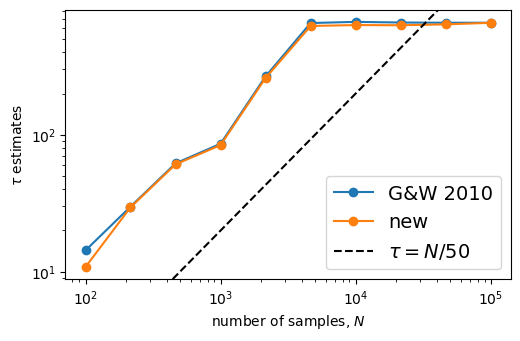

In [7]:
chain = cpo.sampler.get_chain()[:, :, 0].T

# Automated windowing procedure following Sokal (1989)
def auto_window(taus, c):
    m = np.arange(len(taus)) < c * taus
    if np.any(m):
        return np.argmin(m)
    return len(taus) - 1

def autocorr_new(y, c=5.0):
    f = np.zeros(y.shape[1])
    for yy in y:
        f += autocorr_func_1d(yy)
    f /= len(y)
    taus = 2.0 * np.cumsum(f) - 1.0
    window = auto_window(taus, c)
    return taus[window]

def next_pow_two(n):
    i = 1
    while i < n:
        i = i << 1
    return i

# Following the suggestion from Goodman & Weare (2010)
def autocorr_gw2010(y, c=5.0):
    f = autocorr_func_1d(np.mean(y, axis=0))
    taus = 2.0 * np.cumsum(f) - 1.0
    window = auto_window(taus, c)
    return taus[window]

def autocorr_func_1d(x, norm=True):
    x = np.atleast_1d(x)
    if len(x.shape) != 1:
        raise ValueError("invalid dimensions for 1D autocorrelation function")
    n = next_pow_two(len(x))

    # Compute the FFT and then (from that) the auto-correlation function
    f = np.fft.fft(x - np.mean(x), n=2 * n)
    acf = np.fft.ifft(f * np.conjugate(f))[: len(x)].real
    acf /= 4 * n

    # Optionally normalize
    if norm:
        acf /= acf[0]

    return acf

# Compute the estimators for a few different chain lengths
N = np.exp(np.linspace(np.log(100), np.log(chain.shape[1]), 10)).astype(int)
gw2010 = np.empty(len(N))
new = np.empty(len(N))
for i, n in enumerate(N):
    gw2010[i] = autocorr_gw2010(chain[:, :n])
    new[i] = autocorr_new(chain[:, :n])

# Plot the comparisons
plt.loglog(N, gw2010, "o-", label="G&W 2010")
plt.loglog(N, new, "o-", label="new")
ylim = plt.gca().get_ylim()
plt.plot(N, N / 50.0, "--k", label=r"$\tau = N/50$")
plt.ylim(ylim)
plt.xlabel("number of samples, $N$")
plt.ylabel(r"$\tau$ estimates")
plt.legend(fontsize=14);
plt.savefig('arcs_tau.png', dpi=600, bbox_inches='tight')

(100000, 41, 20)
(1000, 41, 20)


True

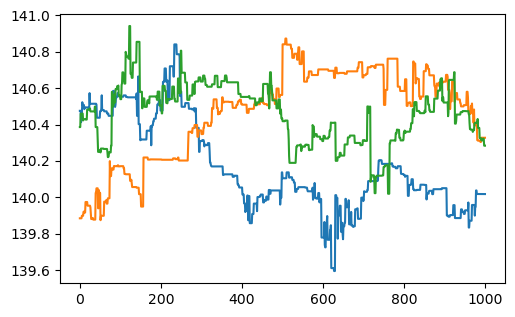

In [8]:
chz = cpo.sampler.get_chain()
nwk = cpo.nwalkers
ndm = cpo.ndim

rlen = chz.shape[0]

print(chz.shape)

burned = chz[-1000::]
#=np.delete(chz, np.s_[rlen-42:rlen], axis=0)
print(burned.shape)
ch1 = burned[:,0,1]
ch2 = burned[:,2,1]
ch3 = burned[:,3,1]
fig,ax=plt.subplots()
ax.plot(ch1)
ax.plot(ch2)
ax.plot(ch3)

cpo.self_check()

In [9]:
# The standard deviation is the square root of the variance.
# Therefore, the variance should be the standard deviation squared.

chz = cpo.sampler.get_chain()
nw = float(cpo.nwalkers)
nd = float(cpo.ndim)
ns = float(chz.shape[0])

print(chz.shape)

mns = np.mean(chz, axis=0)
print("mean shape", mns.shape)
gmn = np.mean(mns, axis=0)
print("gmn  shape", gmn.shape)


wch_variance = 1.0 / (ns - 1.0) * np.sum( (chz - mns)**2.0, axis=0)
print("wchv shape", wch_variance.shape)
wch_var_alt = np.std(chz, axis=0)**2.0
print("w alt shape", wch_var_alt.shape)


bch_variance = ns/(nw - 1.0) * np.sum( (mns - gmn)**2.0, axis=0)
print("bchv shape", bch_variance.shape)

print(bch_variance)

bch_alt_variance = np.std(mns, axis=0)**2.0
print("b alt shape", bch_alt_variance.shape)
print(bch_alt_variance)


ww = (1.0 / nw) * np.sum(wch_variance, axis=0)

wwalt = np.mean(wch_var_alt, axis=0)

print("ww shape", ww.shape)
print("wwalt sh", wwalt.shape)

print("ww", ww)
print("wwalt", wwalt)

t1 = (ns-1.0)*ww / ns
t2 = bch_variance / ns

t1alt = (ns-1.0) * wwalt / ns
t2alt = (bch_alt_variance)

print("t1 shape", t1.shape)
print("t2 shape", t2.shape)

grstat = (t1 + t2) / ww
print(grstat)

gralt = (t1alt + t2alt) / wwalt
print(gralt)


(100000, 41, 20)
mean shape (41, 20)
gmn  shape (20,)
wchv shape (41, 20)
w alt shape (41, 20)
bchv shape (20,)
[2.88965133e+01 5.60851830e+01 7.55173659e+01 1.25781169e+02
 1.11491724e+04 7.99451892e+05 8.69752753e+03 2.26919319e+01
 2.83754382e+01 5.42464659e+01 1.39365249e+02 5.68503725e+03
 1.73888800e+06 3.09307395e+02 5.53036475e-03 4.08108884e-03
 2.59366046e-03 5.63967232e-03 5.11135850e-01 5.18516910e-01]
b alt shape (20,)
[2.81917203e-04 5.47172517e-04 7.36754789e-04 1.22713335e-03
 1.08772414e-01 7.79953065e+00 8.48539271e-02 2.21384701e-04
 2.76833544e-04 5.29233814e-04 1.35966097e-03 5.54637780e-02
 1.69647610e+01 3.01763312e-03 5.39547781e-08 3.98155009e-08
 2.53040045e-08 5.50211933e-08 4.98669122e-06 5.05870156e-06]
ww shape (20,)
wwalt sh (20,)
ww [5.52715626e-02 6.62886929e-02 2.21471051e-01 6.94797110e-01
 2.61399001e+01 9.15689668e+02 1.25005179e+02 6.29288079e-02
 6.09612198e-02 1.26327001e-01 8.71273308e-01 4.21991607e+01
 9.34199328e+02 5.00570557e-01 1.08782295e

In [10]:
  def gsdev(mcmcObject, burn=50) -> np.ndarray :

        # Something is a bit wrong with this.
        # The statistic is starting out at a value of 2
        # in the ARCS test notebook and gently increasing
        # It should not be behaving in this way, there is obviously
        # a mistake in the maths below...

        chains = mcmcObject.sampler.get_chain(discard=burn)
            
        nwk = mcmcObject.nwalkers # "J"
        ndm = mcmcObject.ndim
        nsamps = chains.shape[0] #"L"

        chain_mean = np.mean(chains, axis=0)        
        grand_mean = np.mean(chain_mean, axis=0)

        within_chain_variance = 1.0 / (nsamps - 1.0) * np.sum( (chains - grand_mean)**2.0, axis=0)
        between_chain_variance = nsamps/(nwk - 1.0) * np.sum( (chain_mean - grand_mean)**2.0, axis=0)
        
        ww = (1.0 / nwk) * np.sum(within_chain_variance, axis=0)
        
        t1 = (nsamps-1.0)*ww / nsamps
        t2 = between_chain_variance / nsamps
        
        grstat = (t1 + t2) / ww
        
        return grstat

gs0 = gsdev(cpo, burn=0)
gs10 = gsdev(cpo, burn=10)
gs50 = gsdev(cpo, burn=50)
gs100= gsdev(cpo, burn=100)
gs150= gsdev(cpo, burn=150)

print(gs0)
print(gs10)
print(gs50)
print(gs100)
print(gs150)

[1.00519157 1.00838148 1.0033885  1.00179714 1.00423752 1.00864686
 1.0006853  1.00358333 1.00462363 1.00426622 1.00158707 1.00133542
 1.01827168 1.00613207 1.00504879 1.00767561 1.00336897 1.00088175
 1.00421354 1.00293571]
[1.00519474 1.00839109 1.00341408 1.00184151 1.00423933 1.0086495
 1.00068737 1.0035928  1.00464382 1.00429258 1.0015916  1.00133749
 1.01827513 1.00613368 1.0050584  1.00768146 1.00337041 1.00088199
 1.00421936 1.00293906]
[1.00520654 1.00842678 1.00352051 1.00203785 1.00424672 1.00866011
 1.00069576 1.00362804 1.00472976 1.00440983 1.00160728 1.00134548
 1.01828902 1.00614247 1.00509912 1.00770174 1.00337483 1.00088271
 1.00424252 1.00295206]
[1.00522439 1.00848398 1.00366773 1.00231718 1.00425537 1.00867341
 1.00070648 1.00367384 1.00485038 1.0045621  1.0016178  1.00135591
 1.01830642 1.00615338 1.00516114 1.0077229  1.00338114 1.00088428
 1.00427249 1.00296939]
[1.00525282 1.00857874 1.00381973 1.00263678 1.00426505 1.0086871
 1.00071733 1.00371198 1.00496382 1

Calculating KDE
Using pmb method
   - linear scale
nx 200
slice size 3.9769836729438746


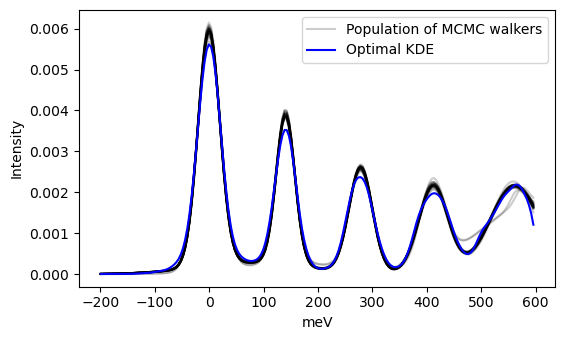

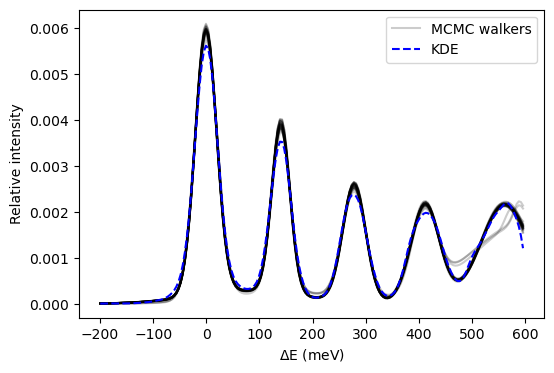

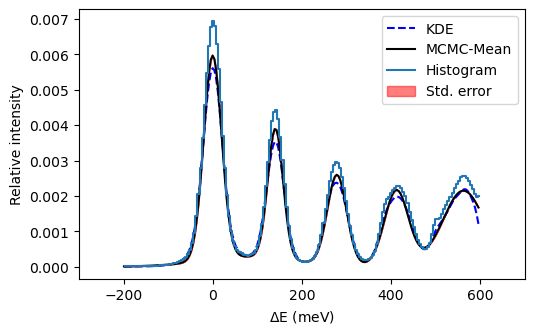

In [11]:
#cpo.plot_LSE_fit(loglog=False, log=False, xlabel='meV')
#cpo.plot_MCMC_fit(method="histo", loglog=False, log=False, xlabel='meV', save="arcs_mcmc_fit.png")

cpo.self_check()

cpo.plot_MCMC_fit(method='kde', loglog=False, log=False, xlabel='meV')
#cpo.plot_MCMC_fit(method='histo', loglog=False, log=False, xlabel='meV')

# Repeat plot manually for paper output

flt = cpo.sampler.get_chain(discard=20, thin=15, flat=True)
inds  = np.random.choice(len(flt), size=30, replace=False)
pt_sum = np.sum(cpo.kdey)

fig,ax=plt.subplots()

for ind in inds:
    smp = flt[ind]
    yfit = cpo.pmf(smp, cpo.kdex, cpo.xmin, cpo.xmax, None)
    ysum = np.sum(yfit)
    scale = pt_sum / ysum 
    yfit = yfit * scale

    if ind == inds[0]:
        ax.plot(cpo.kdex, yfit, color='black', alpha=0.2, label='MCMC walkers')
    else:
        ax.plot(cpo.kdex, yfit, color='black', alpha=0.2)

plt.plot(cpo.kdex, cpo.kdey, ls='--', color='blue', label='KDE')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
#plt.xlim([410, 435])
#plt.ylim([-0.001, 0.001])
plt.legend()
fig.set_size_inches(6,4)
plt.savefig('arcsFigs/arcs_data_subsampled_kde_fit.png', dpi=600, bbox_inches='tight')
plt.show()

# Plot showing the average of the PDFs over all walkers?
inds = np.arange(len(flt))


yfit = np.zeros((len(flt),cpo.kdex.size))

for ind in range(len(flt)):
    smp = flt[ind]
    yfit[ind] = cpo.pmf(smp, cpo.kdex, cpo.xmin, cpo.xmax, None)

ysum = np.sum(yfit, axis=0)

ymean = ysum / len(flt) #np.mean(yfit, axis=0)
ystd = np.std(yfit, axis=0)
ystd = ystd / np.sqrt(len(inds))

                
ysum = np.sum(ymean)
scale = pt_sum / ysum
ymean = ymean * scale
ystd = ystd * scale

stepsum = np.sum(fullhisto_y)
stepscale = pt_sum / stepsum

plt.plot(cpo.kdex, cpo.kdey, ls='--', color='blue', label='KDE')
plt.plot(cpo.kdex, ymean, color='black', label='MCMC-Mean')
plt.step(fullhisto_x, fullhisto_y*stepscale, where='mid', label='Histogram')
plt.fill_between(cpo.kdex, ymean-ystd, ymean+ystd, color='red', alpha=0.5, label='Std. error')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
#plt.xlim([410, 435])
#plt.ylim([0.0014, 0.00195])
plt.legend()
plt.xlim(-300,700)
fig.set_size_inches(6,4)
plt.savefig('arcsFigs/arcs_data_subsampled_kde_fit_mean.png', dpi=600, bbox_inches='tight')
plt.show()

stdd 0.2356966844815936
stdd 0.25852505208308235
stdd 0.47138688012667557
stdd 0.8342765100854739
stdd 5.123320317851902
stdd 30.38881442537159
stdd 11.18430966248914
stdd 0.2512957686573483
stdd 0.2474620047154809
stdd 0.3561670561965554
stdd 0.9341435948984608
stdd 6.500323257684596
stdd 30.84079679832159
stdd 0.7096359517919764
stdd 0.003306368922206146
stdd 0.002304341394702023
stdd 0.002770525657037424
stdd 0.007952510002250297
stdd 0.03478787779849731
stdd 0.04195508649083224
-0.5320350756385711 +/- 0.000116402295547325 using method mean


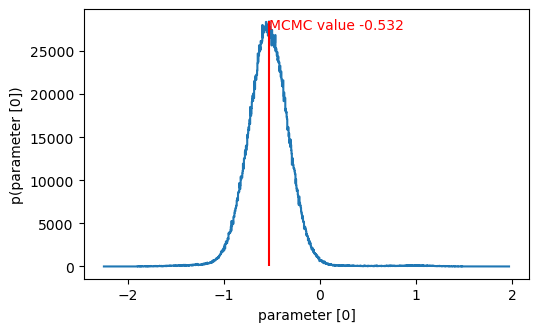

fwhm 131.205923123689
fwhm 131.7145249776985
fwhm 131.57588038492048
fwhm 128.0085489329736
fwhm 100.27636054421765
fwhm 1.2773811213951731
fwhm 127.76225388421744
fwhm 129.2136193488625
fwhm 134.51559389515592
fwhm 129.99840292581268
fwhm 122.99192565508827
fwhm 97.46972303542645
fwhm 19.334260731319574
fwhm 2.8507671842878386
fwhm 132.70309863002421
fwhm 130.61031031656069
fwhm 129.25182507799911
fwhm 124.20963735305122
fwhm 53.02629865428264
fwhm 37.49360642936165
-0.5292982706183902 +/- 0.0381468995264958 using method peak


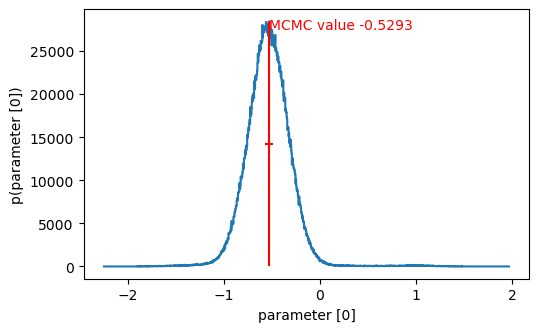

In [12]:
lookat=0
#cpo.plot_MCMC_parameter_distribution(lookat, compare=True)
cpo.plot_MCMC_parameter_distribution(lookat, compare=False, method='mean', savename='arcsFigs/arcs_parameter_mean.png')
cpo.plot_MCMC_parameter_distribution(lookat, compare=False, method='peak', savename='arcsFigs/arcs_parameter_peak.png')


In [13]:
print("PEAK METHOD:")
mcpparams, mcperr = cpo.get_MCMC_parameters(method='peak')
print(mcpparams)
print(mcperr)

print()
print("MEAN METHOD:")
mcparams, mcerr = cpo.get_MCMC_parameters(method='mean')
print(mcparams)
print(mcerr)

print()
print("LSE on full data set")
lsparams = ema1.get_lse_param_values()


lserrors = ema1.get_lse_param_errors()
print(lsparams)
print(lserrors)

import pandas

pn = ema1.get_lse_param_names()
pn = pn[1:]

df = pandas.DataFrame({"PARAMETER": pn, "LSE": lsparams[1:], "LSE_ERR": lserrors[1:], "BAYES": mcparams, "BAYES_ERR": mcerr, "BAYES-PEAK": mcpparams, "BAYES-PEAK-ERR": mcperr})
print(df)

PEAK METHOD:
fwhm 131.205923123689
fwhm 131.7145249776985
fwhm 131.57588038492048
fwhm 128.0085489329736
fwhm 100.27636054421765
fwhm 1.2773811213951731
fwhm 127.76225388421744
fwhm 129.2136193488625
fwhm 134.51559389515592
fwhm 129.99840292581268
fwhm 122.99192565508827
fwhm 97.46972303542645
fwhm 19.334260731319574
fwhm 2.8507671842878386
fwhm 132.70309863002421
fwhm 130.61031031656069
fwhm 129.25182507799911
fwhm 124.20963735305122
fwhm 53.02629865428264
fwhm 37.49360642936165
[-5.29298271e-01  1.40251735e+02  2.78333780e+02  4.11980137e+02
  5.60694847e+02  6.00000012e+02  7.62461383e+01  2.00446001e+01
  1.71504217e+01  2.16403260e+01  2.70087607e+01  4.45243185e+01
  1.00000062e+02  1.00000000e+02  2.88045621e-01  1.57049491e-01
  1.38442196e-01  1.43410485e-01  1.86351780e-01  1.03129008e-02]
[0.0381469  0.03829477 0.03825446 0.03721729 0.02915442 0.00037139
 0.03714568 0.03756766 0.03910916 0.03779582 0.03575876 0.02833841
 0.00562126 0.00082883 0.03858219 0.03797373 0.03757876

In [14]:
mcpparams

array([-5.29298271e-01,  1.40251735e+02,  2.78333780e+02,  4.11980137e+02,
        5.60694847e+02,  6.00000012e+02,  7.62461383e+01,  2.00446001e+01,
        1.71504217e+01,  2.16403260e+01,  2.70087607e+01,  4.45243185e+01,
        1.00000062e+02,  1.00000000e+02,  2.88045621e-01,  1.57049491e-01,
        1.38442196e-01,  1.43410485e-01,  1.86351780e-01,  1.03129008e-02])

In [73]:
# Maybe try an MLE like Thomas did, to compare.

def negLLF(theta):
    raiseError = False
    result = 0.0

    elmu, mu1, mu2, mu3, mu4, mubg1, mubg2, elsigma, s1, s2, s3, s4, sbg1, sbg2, me, m1, m2, m3, m4, mbg1 = theta

    pweights = cpo.weights
    data = cpo.data
        
    mvals = simplex_weights(np.array([me, m1, m2, m3, m4, mbg1]))

    el = mvals[0] * norm.pdf(data, scale=elsigma, loc=elmu) / gaussian_integral(ema1.xmin, ema1.xmax, elmu, elsigma)
    l1 = mvals[1] * norm.pdf(data, scale=s1, loc=mu1) / gaussian_integral(ema1.xmin, ema1.xmax, mu1, s1)
    l2 = mvals[2] * norm.pdf(data, scale=s2, loc=mu2) / gaussian_integral(ema1.xmin, ema1.xmax, mu2, s2)
    l3 = mvals[3] * norm.pdf(data, scale=s3, loc=mu3) / gaussian_integral(ema1.xmin, ema1.xmax, mu3, s3)
    l4 = mvals[4] * norm.pdf(data, scale=s4, loc=mu4) / gaussian_integral(ema1.xmin, ema1.xmax, mu4, s4)
    bg1= mvals[5] * norm.pdf(data, scale=sbg1, loc=mubg1) / gaussian_integral(ema1.xmin, ema1.xmax, mubg1, sbg1)
    bg2= mvals[6] * cauchy.pdf(data, scale=sbg2, loc=mubg2) / cauchy_integral(ema1.xmin, ema1.xmax, sbg2)

    # Guard against zero values in each term
    minval = 1.0E-300

    msk = el < minval
    el[msk] = minval

    msk = l1 < minval
    l1[msk] = minval

    msk = l2 < minval
    l2[msk] = minval

    msk = l3 < minval
    l3[msk] = minval

    msk = l4 < minval
    l4[msk] = minval

    msk = bg1 < minval
    bg1[msk] = minval

    msk = bg2 < minval
    bg2[msk] = minval

    
 #   try:
    lel = np.log(el)
    ll1 = np.log(l1)
    ll2 = np.log(l2)
    ll3 = np.log(l3)
    ll4 = np.log(l4)
    lbg1 = np.log(bg1)
    lbg2 = np.log(bg2)

    lt1 = np.logaddexp(lel, ll1)
    lt2 = np.logaddexp(lt1, ll2)
    lt3 = np.logaddexp(lt2, ll3)
    lt4 = np.logaddexp(lt3, ll4)
    lt5 = np.logaddexp(lt4, lbg1)
    lt6 = np.logaddexp(lt5, lbg2)

    lll = np.sum(lt6 * pweights)
    
    result = lll

    return (-result)

mleResult = sp.optimize.minimize(negLLF, same_as_least_squares, method='nelder-mead',
               options={'xatol': 1e-8, 'disp': True})


/var/folders/th/9shc9qg10f7brtgj6hbfmnpw0000gn/T/ipykernel_18060/1993106469.py:69: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  mleResult = sp.optimize.minimize(negLLF, same_as_least_squares, method='nelder-mead',


In [23]:
mleparams = mleResult.x
print(mleResult.x)

NameError: name 'mleResult' is not defined

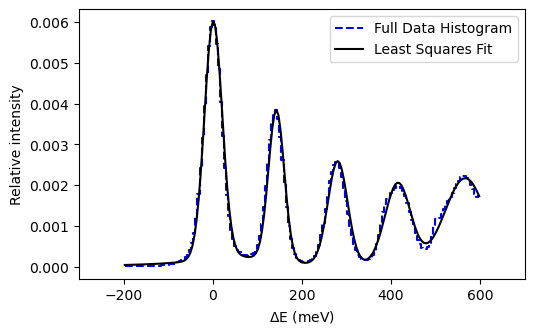

In [15]:
# Use these parameter values to calculate a PMF from the master equation

mcmc_fit_line = big_lse_pdf(fullhisto_x, 
                            1.0,
                            mcparams[0],
                            mcparams[1],
                            mcparams[2],
                            mcparams[3],
                            mcparams[4],
                            mcparams[5],
                            mcparams[6],
                            mcparams[7],
                            mcparams[8],
                            mcparams[9],
                            mcparams[10],
                            mcparams[11],
                            mcparams[12],
                            mcparams[13],
                            mcparams[14],
                            mcparams[15],
                            mcparams[16],
                            mcparams[17],
                            mcparams[18],
                            mcparams[19])

#mle_fit_line = big_lse_pdf(fullhisto_x, 
#                            1.0, 
#                            mleparams[0],
#                            mleparams[1],
#                            mleparams[2],
#                            mleparams[3],
#                            mleparams[4],
#                            mleparams[5],
#                            mleparams[6],
#                            mleparams[7],
#                            mleparams[8],
#                            mleparams[9],
#                            mleparams[10],
#                            mleparams[11],
#                            mleparams[12],
#                            mleparams[13],
#                            mleparams[14],
#                            mleparams[15],
#                            mleparams[16],
#                            mleparams[17],
#                            mleparams[18],
#                            mleparams[19])

mcmc_background_line = big_background_pdf(fullhisto_x, 
                            1.0,
                            mcparams[0],
                            mcparams[1],
                            mcparams[2],
                            mcparams[3],
                            mcparams[4],
                            mcparams[5],
                            mcparams[6],
                            mcparams[7],
                            mcparams[8],
                            mcparams[9],
                            mcparams[10],
                            mcparams[11],
                            mcparams[12],
                            mcparams[13],
                            mcparams[14],
                            mcparams[15],
                            mcparams[16],
                            mcparams[17],
                            mcparams[18],
                            mcparams[19])

hsum = np.sum(fullhisto_y)
hssum = np.sum(subsample_histo_y)
lsum = np.sum(mcmc_fit_line)
hscale = lsum/hsum
hsscale = 0.065/hssum


fsum = np.sum(full_data_fit_line)
fscale = lsum/fsum


plt.step(fullhisto_x, fullhisto_y*hscale, color='blue', where='mid', ls='--',label='Full Data Histogram')
plt.plot(fullhisto_x, full_data_fit_line*fscale, color='black', label='Least Squares Fit')

plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
#plt.xlim([410, 435])
#plt.ylim([0.0014, 0.00195])
plt.legend()
plt.xlim(-300,700)
fig.set_size_inches(6,4)
#plt.savefig('arcsFigs/arcs_data_subsampled_kde_fit_mean.png', dpi=600, bbox_inches='tight')
plt.show()



sscale:  124.518265
p-ratio:  5.117647058823529


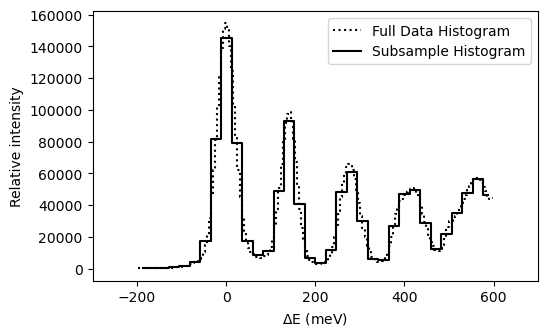

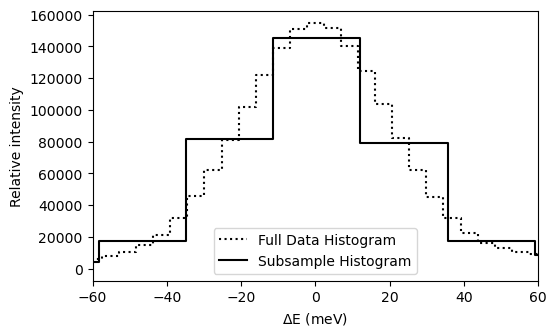

In [26]:
fsum = np.sum(fullhisto_y)
ssum = np.sum(subsample_histo_y)
sscale = fsum  / ssum

pratio = fullhisto_y.size / subsample_histo_y.size

print("sscale: ", sscale)
print("p-ratio: ", pratio)

plt.step(fullhisto_x, fullhisto_y, color='black', where='mid', ls=':', label='Full Data Histogram')
plt.step(subsample_histo_x, subsample_histo_y*sscale/pratio, color='black', where='mid', label='Subsample Histogram')
#plt.plot(fullhisto_x, mle_fit_line, color='black', label='MLE')

plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
#plt.xlim([410, 435])
#plt.ylim([0.0014, 0.00195])
plt.legend()
plt.xlim(-300,700)
fig.set_size_inches(6,4)
plt.show()

plt.step(fullhisto_x, fullhisto_y, color='black', where='mid', ls=':', label='Full Data Histogram')
plt.step(subsample_histo_x, subsample_histo_y*sscale/pratio, color='black', where='mid', label='Subsample Histogram')
#plt.plot(fullhisto_x, mle_fit_line, color='black', label='MLE')

plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
#plt.xlim([410, 435])
#plt.ylim([0.0014, 0.00195])
plt.legend()
plt.xlim(-60,60)
fig.set_size_inches(6,4)
plt.savefig('arcsFigs/arcs_data_two_histo_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

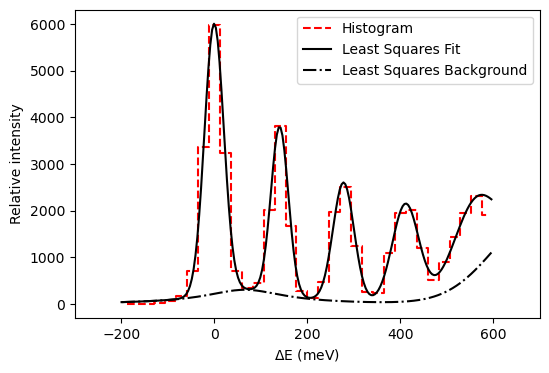

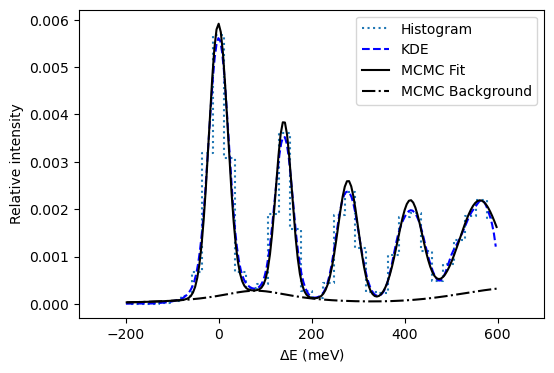

In [27]:
fsum = np.sum(sub_data_fit_line)
fscale = hssum * (sub_data_fit_line.size) / (fsum*subsample_histo_y.size)

fig,ax=plt.subplots()
plt.step(subsample_histo_x, subsample_histo_y, color='red', ls='--', where='mid', label='Histogram')
#plt.plot(cpo.kdex, cpo.kdey, color='blue', ls=':', label = 'KDE of Subsample')
plt.plot(cpo.kdex, sub_data_fit_line, color='black', label='Least Squares Fit')
plt.plot(cpo.kdex, sub_data_background_line, ls='-.', color='black', label='Least Squares Background')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.legend()
fig.set_size_inches(6,4)
plt.xlim(-300,700)
plt.savefig('arcsFigs/arcs_data_subsample_lse_analysis.png', dpi=600, bbox_inches='tight')
plt.show()

fig,ax=plt.subplots()
plt.step(subsample_histo_x, subsample_histo_y * (np.sum(mcmc_fit_line) * subsample_histo_y.size / (np.sum(subsample_histo_y)*mcmc_fit_line.size)), ls=':', where='mid', label='Histogram')
plt.plot(cpo.kdex, cpo.kdey, color='blue', ls='--', label = 'KDE')
plt.plot(fullhisto_x, mcmc_fit_line, color='black', label='MCMC Fit')
plt.plot(fullhisto_x, mcmc_background_line, ls='-.', color='black', label='MCMC Background')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.legend()
fig.set_size_inches(6,4)
plt.xlim(-300,700)
plt.savefig('arcsFigs/arcs_data_subsample_mcmc_analysis.png', dpi=600, bbox_inches='tight')
plt.show()

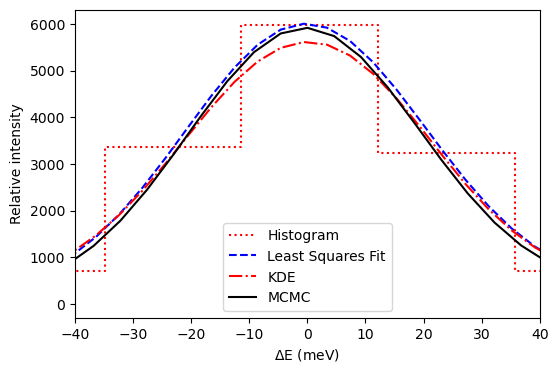

In [31]:
fig,ax=plt.subplots()
plt.step(subsample_histo_x, subsample_histo_y, color='red', ls=':', where='mid', label='Histogram')
#plt.plot(cpo.kdex, cpo.kdey, color='blue', ls=':', label = 'KDE of Subsample')
plt.plot(cpo.kdex, sub_data_fit_line*fscale, color='blue', ls='--', label='Least Squares Fit')

plt.plot(cpo.kdex, cpo.kdey*1000000, color='red', ls='-.', label = 'KDE')

#plt.plot(fullhisto_x, mle_fit_line*2300000, color='green', label='MLE')
plt.plot(fullhisto_x, mcmc_fit_line*1000000, color='black', label='MCMC')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.legend()
fig.set_size_inches(6,4)
plt.xlim(-40,40)
plt.show()

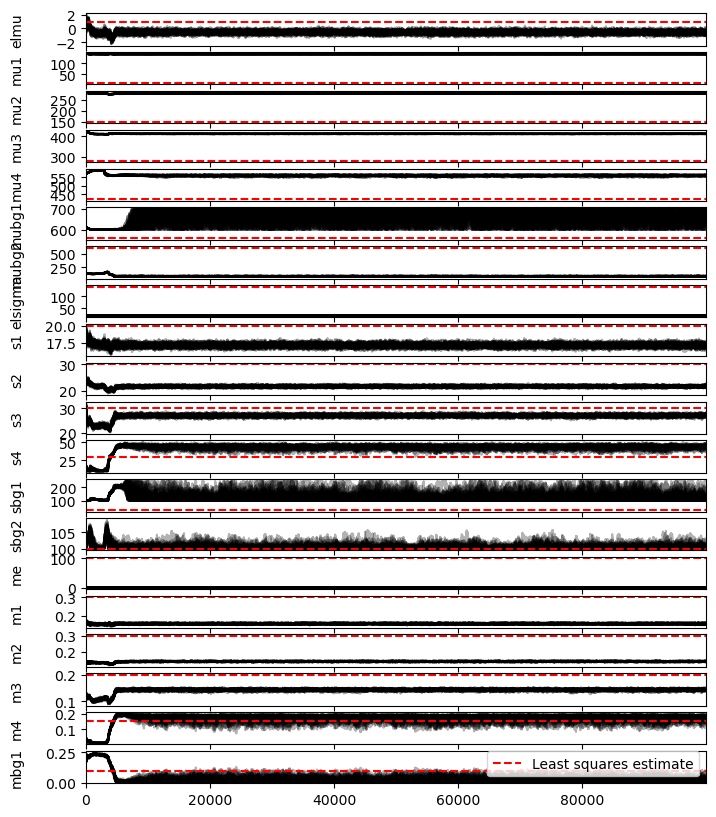

In [32]:
cpo.plot_MCMC_convergences()

## Event-dependent convergence study

In [33]:
print(same_as_least_squares)
print(lse_starting_parameters)

[2.00e+00 1.45e+02 2.80e+02 4.20e+02 5.60e+02 6.20e+02 1.40e+02 2.00e+01
 3.00e+01 3.00e+01 3.00e+01 3.00e+01 1.05e+02 1.05e+02 1.10e-01 1.10e-01
 1.10e-01 1.10e-01 1.10e-01 1.10e-01]
Parameters([('amplitude', <Parameter 'amplitude', value=1.0, bounds=[0.0:inf]>), ('elmu', <Parameter 'elmu', value=10.0, bounds=[-100.0:100.0]>), ('mu1', <Parameter 'mu1', value=150.0, bounds=[100.0:200.0]>), ('mu2', <Parameter 'mu2', value=280.0, bounds=[200.0:350.0]>), ('mu3', <Parameter 'mu3', value=420.0, bounds=[350.0:450.0]>), ('mu4', <Parameter 'mu4', value=560.0, bounds=[500.0:620.0]>), ('mubg1', <Parameter 'mubg1', value=620.0, bounds=[600.0:700.0]>), ('mubg2', <Parameter 'mubg2', value=140.0, bounds=[0.0:200.0]>), ('elsigma', <Parameter 'elsigma', value=20.0, bounds=[10.0:100.0]>), ('s1', <Parameter 's1', value=30.0, bounds=[10.0:100.0]>), ('s2', <Parameter 's2', value=30.0, bounds=[10.0:100.0]>), ('s3', <Parameter 's3', value=30.0, bounds=[10.0:100.0]>), ('s4', <Parameter 's4', value=30.0, boun

In [34]:
# The original version of this code in the first draft of the paper erroneously used the ".subsample" function.
# Each time it's called, subsample takes a random set of data.
#
# What we actually need to do is take the first nn data points to simulate having taken different measurement collection times, so that
# the first points in the data set are always the same, and the last points are the new ones.
# This should have the effect of removing huge fluctuation errors in the convergence curves.
# I left in the subsample as a comment, and put in the correct code directly below it.


assumed_param_values = np.copy(mcparams)

RANDOM_SEED = 1
np.random.seed(seed=RANDOM_SEED)

maxsiz = np.log10(evs.size)
print(evs.size)
print(maxsiz)
evreps=10
n_evs = np.logspace(2, maxsiz, evreps).astype(int)
print(n_evs)
n_evs[-1]=evs.size
print(n_evs)

lse_results = np.zeros((evreps, mcparams.size+1))
lse_errors  = np.zeros((evreps, mcparams.size+1))
mcmc_results = np.zeros((evreps, mcparams.size))
mcmc_errors = np.zeros((evreps, mcparams.size))


lsMinEvents = 12000
mcmcMinEvents = 10
lsMaxEvents = 10000000
mcmcMaxEvents = 110000


rep = 0

for nn in n_evs:
    print("Rep", rep+1, "/", evreps, "|", nn, "/", evs.size)
    print("Subsampling...")
    sse = ema1.subsample(nn, randomize=False)
    # Manually subsample the first nn points instead of randomly subsampling them

    sse.lpf = log_prior_function
    sse.pmf = probability_mass_function
    sse.llf = log_likelihood_function


    if nn >= lsMinEvents and nn <= lsMaxEvents:
        print("Least Squares Analysis...")
        sse.least_squares_parameters = copy.deepcopy(lse_starting_parameters)
        sse.calculate_histogram()
        sse.lse_fit()
        #sse.plot_LSE_fit(loglog=False, log=False, xlabel='meV')


        lse_results[rep,:] = sse.get_lse_param_values()
        lse_errors[rep,:] = sse.get_lse_param_errors()
    else:
        print("Skipping Least Squares Analysis (too few events for stable fit)")

    if nn >= mcmcMinEvents and nn <= mcmcMaxEvents:
        print("MCMC Analysis...")
        sse.nwalkers=32
        # (on plots of MCMC_parameter_distribution) 

        sse.theta_seed = same_as_least_squares
        sse.MCMC_fit(nburn=7000, niter=50000, jitter=-2)

        mcmc_results[rep,:], mcmc_errors[rep,:] = sse.get_MCMC_parameters(method='mean')
    else:
        print("Skipping MCMC Analysis (too many events to run on a laptop in sensible time)")

    rep = rep + 1

print("Convergence loop complete.")

5603322
6.748445580312473
[    100     336    1135    3826   12894   43453  146430  493441 1662801
 5603322]
[    100     336    1135    3826   12894   43453  146430  493441 1662801
 5603322]
Rep 1 / 10 | 100 / 5603322
Subsampling...
Subsampling in order.
Skipping Least Squares Analysis (too few events for stable fit)
MCMC Analysis...
MCMC launch
Burn in:


100%|███████████████████████████████████████| 7000/7000 [01:46<00:00, 65.75it/s]


Sampling:


100%|█████████████████████████████████████| 50000/50000 [12:29<00:00, 66.73it/s]


MCMC sampling complete.
stdd 4.198517307375276
stdd 5.249172562581864
stdd 12.347709067217778
stdd 6.705449787118329
stdd 26.644941034064104
stdd 28.673951643446554
stdd 55.716815220027755
stdd 3.5599484450113175
stdd 4.807420733236727
stdd 13.438151369264249
stdd 7.595529215962394
stdd 22.53840278813244
stdd 42.75500842335126
stdd 44.233131258957876
stdd 0.04450774690149841
stdd 0.03967966957467435
stdd 0.036045455511641525
stdd 0.04067535172809404
stdd 0.06953534042204725
stdd 0.07862877566916612
Rep 2 / 10 | 336 / 5603322
Subsampling...
Subsampling in order.
Skipping Least Squares Analysis (too few events for stable fit)
MCMC Analysis...
MCMC launch
Burn in:


...

MCMC sampling complete.
stdd 0.3836934013890717
stdd 0.4390418206061938
stdd 0.5578926334820971
stdd 0.8194377314427598
stdd 3.4513009750038584
stdd 28.426886154860078
stdd 6.46122570227211
stdd 0.3568023594265992
stdd 0.42148219288691025
stdd 0.45845839462053245
stdd 0.792597855140536
stdd 3.6992212889908886
stdd 36.27882305413466
stdd 1.6196852771587475
stdd 0.004728140225351649
stdd 0.004072458778387465
stdd 0.003396249437553235
stdd 0.0054865802525871634
stdd 0.024108734033492934
stdd 0.026759205916313086
Rep 6 / 10 | 43453 / 5603322
Subsampling...
Subsampling in order.
Least Squares Analysis...
MCMC Analysis...
MCMC launch
Burn in:


100%|███████████████████████████████████████| 7000/7000 [37:14<00:00,  3.13it/s]


Sampling:


100%|███████████████████████████████████| 50000/50000 [3:27:10<00:00,  4.02it/s]


MCMC sampling complete.
stdd 0.203422556946356
stdd 0.2470050661930661
stdd 0.30464756259456405
stdd 0.44557644838020577
stdd 3.1642441168601176
stdd 26.199735764015173
stdd 3.3014583661639088
stdd 0.1838505183375096
stdd 0.22411858406585625
stdd 0.2538688441646124
stdd 0.4019725261988054
stdd 2.5397936497494187
stdd 25.99790170380123
stdd 0.5488075988861425
stdd 0.0025022043083106995
stdd 0.0021666761935772794
stdd 0.0018182596527346623
stdd 0.002650447986604689
stdd 0.01990590158563152
stdd 0.020577373452011574
Rep 7 / 10 | 146430 / 5603322
Subsampling...
Subsampling in order.
Least Squares Analysis...
Skipping MCMC Analysis (too many events to run on a laptop in sensible time)
Rep 8 / 10 | 493441 / 5603322
Subsampling...
Subsampling in order.
Least Squares Analysis...
Skipping MCMC Analysis (too many events to run on a laptop in sensible time)
Rep 9 / 10 | 1662801 / 5603322
Subsampling...
Subsampling in order.
Least Squares Analysis...
Skipping MCMC Analysis (too many events to run 

In [35]:
def p_conv_plot(item, param_name='', Bayes=True, LSE=True, savename='', correct=np.inf, ylims=[np.inf, np.inf]):

    # Least squares parameters
    pnams = sse.get_lse_param_names()
    pnam = pnams[item+1]
    
    lsnevs = n_evs
    lsvalues = lse_results[:,item+1]
    lserrs = lse_errors[:,item+1]

    lsmask = lsvalues != 0.0
    lsnevs = lsnevs[lsmask]
    lsvalues = lsvalues[lsmask]
    lserrs = lserrs[lsmask]
    
    lsbtop = lsvalues+lserrs
    lsbbot = lsvalues-lserrs
    lswtop = np.amax(lsvalues)
    lswbot = np.amin(lsvalues)

    # Bayesian parameters
    mcnevs = n_evs
    mcvalues = mcmc_results[:,item]
    mcerrs = mcmc_errors[:,item]

    mcmask = mcvalues != 0.0
    mcvalues = mcvalues[mcmask]
    mcerrs = mcerrs[mcmask]
    mcnevs = mcnevs[mcmask]
    
    
    mcbtop = mcvalues+mcerrs
    mcbbot = mcvalues-mcerrs
    mcwtop = np.amax(mcvalues)
    mcwbot = np.amin(mcvalues)
    
    if np.isfinite(correct):
        wtop = np.amax([lswtop, mcwtop, correct])
        wbot = np.amin([lswbot, mcwbot, correct])
    else:
        wtop = np.amax([lswtop, mcwtop])
        wbot = np.amin([lswbot, mcwbot])

    wspan = wtop - wbot
    wpad = wspan * 0.1
    wtop = wtop + np.abs(wpad)
    wbot = wbot - np.abs(wpad)

        
    fig, ax = plt.subplots()
    if LSE:
        ax.plot(lsnevs, lsvalues, color='blue', label='LSE')
        ax.fill_between(lsnevs, lsbbot, lsbtop, color='blue', alpha=0.15, label='LSE std. err')
        ax.set_ylim([wbot, wtop])
        ax.set_xlabel("# events")
        ax.set_ylabel(pnam + "Value")
        if param_name != '':
            ax.set_ylabel(param_name)

    if Bayes:
        ax.plot(mcnevs, mcvalues, color='red', label='Bayes')
        ax.fill_between(mcnevs, mcbbot, mcbtop, color='red', alpha=0.15, label='Bayes std. err')

    if np.isfinite(correct):
        xmin=np.amin(mcnevs)
        xmax=np.amax(lsnevs)
        plt.hlines(correct, xmin, xmax, label='Visual estimate', ls='--', color='orange')


    if np.isfinite(ylims).all():
        plt.ylim(ylims)
    
    
    plt.xscale('log')
    plt.yscale('linear')
    ax.legend()

        

    if savename != '':
        plt.savefig(savename, dpi=600, bbox_inches='tight')
        plt.show()
    
    #print(sse.get_lse_param_names())

    

### Elastic Line Parameters

What are the correct values?  lets inspect the kde of the full data set.

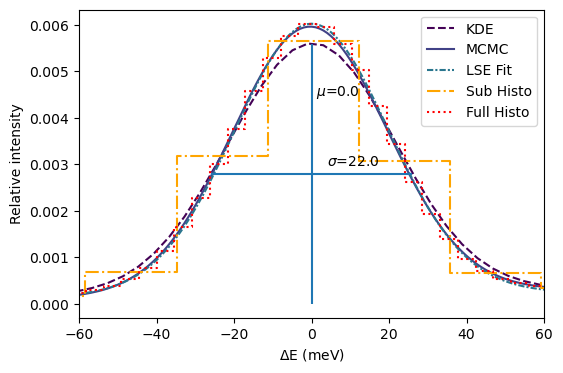

In [36]:
#ema1.plot_kde(loglog=False,log=False, xlabel='meV', method='silverman')


mu=0.0
sig=22.0
normval=1.8
ht=0.0056

px=np.arange(-200,600,1)
nrm = sp.stats.norm(loc=mu,scale=sig)
py=nrm.pdf(px)/normval

ema1.pmf = probability_mass_function

lstrimp = np.delete(lsparams, 0)

mcmcy = ema1.pmf(mcpparams, px, ema1.xmin, ema1.xmax, None)
lsey = ema1.pmf(lstrimp, px, ema1.xmin, ema1.xmax, None)

mcmc_sum = np.sum(mcmcy)
mcmc_size = mcmcy.size

lsey_sum = np.sum(lsey)
lsey_size = lsey.size

py_sum = np.sum(py)
py_size = py.size

kde_sum = np.sum(ema1.kdey)
kde_size = ema1.kdey.size

hist_sum = np.sum(ema1.histy)
hist_size = ema1.histy.size

sub_hist_sum = np.sum(subsample_histo_y)
sub_hist_size = subsample_histo_y.size

# Check everything is normalised to KDE line, maybe it's already done upstream...

sub_hist_scale = (kde_sum / sub_hist_sum) * (sub_hist_size / kde_size)
hist_scale = (kde_sum / hist_sum) * (hist_size / kde_size)
lsey_scale = (kde_sum / lsey_sum) * (lsey_size / kde_size)
mcmc_scale = (kde_sum / mcmc_sum) * (mcmc_size / kde_size)

import matplotlib as mpl
colors = mpl.colormaps['viridis'].colors

fig,ax=plt.subplots()
plt.plot(ema1.kdex, ema1.kdey, ls='--', label='KDE', color=colors[1])
plt.plot(px, mcmcy * mcmc_scale,label='MCMC', color=colors[50])
plt.plot(px, lsey * lsey_scale, ls=(0, (3, 1, 1, 1)), label='LSE Fit', color=colors[100])
#plt.plot(px, py, ls='--', label='Manual', color=colors[200])
plt.step(subsample_histo_x, subsample_histo_y * sub_hist_scale, color='orange', ls='-.', where='mid', label='Sub Histo')
plt.step(ema1.histx, ema1.histy * hist_scale, color='red', ls=':', where='mid', label='Full Histo')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.vlines(mu, 0.0, ht)
plt.hlines(ht/2.0, mu-2.355*sig/2.0, mu+2.355*sig/2.0)
ax.text(mu+1, ht*0.8, "$\mu$=" + str(mu))
ax.text(mu+4, ht*0.53, "$\sigma$=" + str(sig))
fig.set_size_inches(6,4)
plt.xlim([-60,60])
plt.legend()
plt.savefig('arcsFigs/arcs_fulldata_kde_elastic.png', dpi=600, bbox_inches='tight')
plt.show()

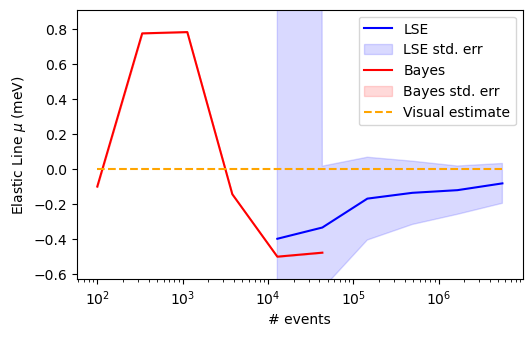

In [37]:
parameter_no = 0
p_conv_plot(parameter_no, param_name='Elastic Line $\mu$ (meV)', savename='arcsFigs/arcs_elastic_mu.png', correct=0.0)
#p_conv_plot(parameter_no, LSE=False)

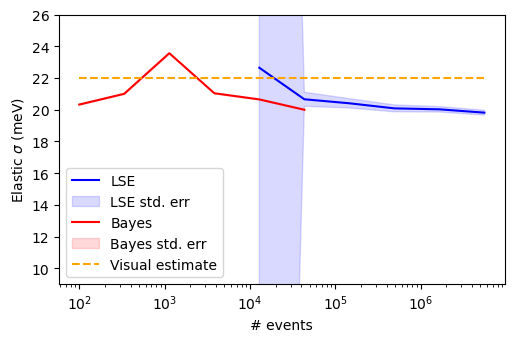

In [38]:
parameter_no = 7
p_conv_plot(parameter_no, param_name='Elastic $\sigma$ (meV)', savename='arcsFigs/arcs_elastic_sigma.png', correct=22.0, ylims=[9, 26])
#p_conv_plot(parameter_no, LSE=False)

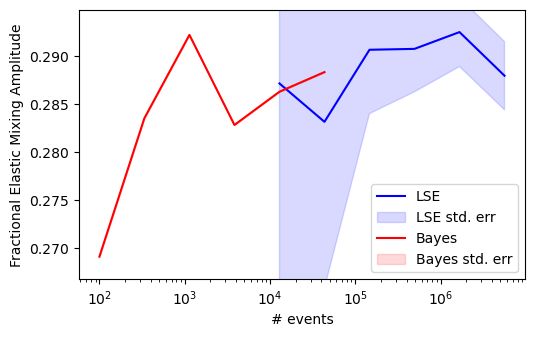

In [39]:
parameter_no = 14
p_conv_plot(parameter_no, param_name='Fractional Elastic Mixing Amplitude', savename='arcsFigs/arcs_elastic_amplitude.png')
#p_conv_plot(parameter_no, LSE=False)

### First Excitation Line Parameters

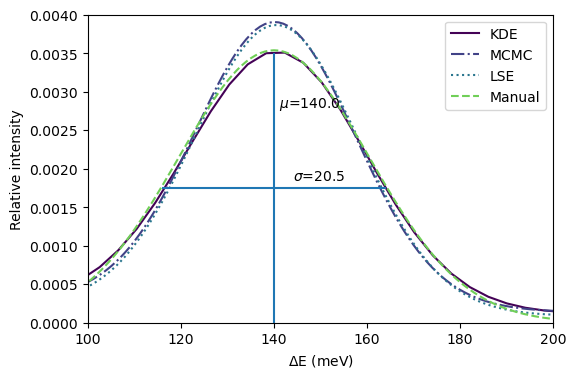

In [40]:
mu=140.0
sig=20.5
normval=5.5
ht=0.0035

px=np.arange(-200,600,1)
nrm = sp.stats.norm(loc=mu,scale=sig)
py=nrm.pdf(px)/normval

ema1.pmf = probability_mass_function

lstrimp = np.delete(lsparams, 0)

mcmcy = ema1.pmf(mcpparams, px, ema1.xmin, ema1.xmax, None)
lsey = ema1.pmf(lstrimp, px, ema1.xmin, ema1.xmax, None)

mcmc_sum = np.sum(mcmcy)
mcmc_size = mcmcy.size

lsey_sum = np.sum(lsey)
lsey_size = lsey.size

py_sum = np.sum(py)
py_size = py.size

kde_sum = np.sum(ema1.kdey)
kde_size = ema1.kdey.size

hist_sum = np.sum(ema1.histy)
hist_size = ema1.histy.size

sub_hist_sum = np.sum(subsample_histo_y)
sub_hist_size = subsample_histo_y.size

# Check everything is normalised to KDE line, maybe it's already done upstream...

sub_hist_scale = (kde_sum / sub_hist_sum) * (sub_hist_size / kde_size)
hist_scale = (kde_sum / hist_sum) * (hist_size / kde_size)
lsey_scale = (kde_sum / lsey_sum) * (lsey_size / kde_size)
mcmc_scale = (kde_sum / mcmc_sum) * (mcmc_size / kde_size)



fig,ax=plt.subplots()
#plt.plot(ema1.kdex, ema1.kdey)
#plt.plot(px, py, ls='--')
plt.plot(ema1.kdex, ema1.kdey, label='KDE', color=colors[1])
plt.plot(px, mcmcy*mcmc_scale, ls='-.',label='MCMC', color=colors[50])
plt.plot(px, lsey * lsey_scale, ls=':', label='LSE', color=colors[100])
plt.plot(px, py, ls='--', label='Manual', color=colors[200])

plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.vlines(mu, 0.0, ht)
plt.hlines(ht/2.0, mu-2.355*sig/2.0, mu+2.355*sig/2.0)
ax.text(mu+1, ht*0.8, "$\mu$=" + str(mu))
ax.text(mu+4, ht*0.53, "$\sigma$=" + str(sig))
fig.set_size_inches(6,4)
plt.xlim([100,200])
plt.ylim([0.0, 0.004])
plt.legend()
plt.savefig('arcsFigs/arcs_fulldata_kde_ex1.png', dpi=600, bbox_inches='tight')
plt.show()

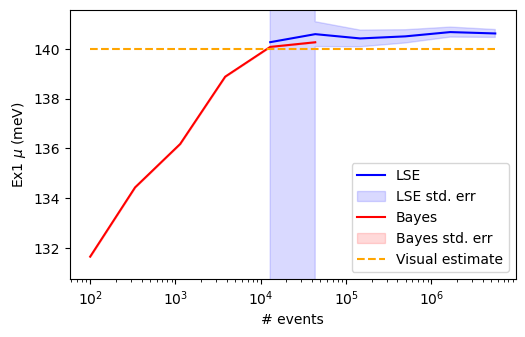

In [41]:
parameter_no = 1
p_conv_plot(parameter_no, param_name='Ex1 $\mu$ (meV)', savename='arcsFigs/arcs_ex1_mu.png', correct=140.0)
#p_conv_plot(parameter_no, LSE=False)

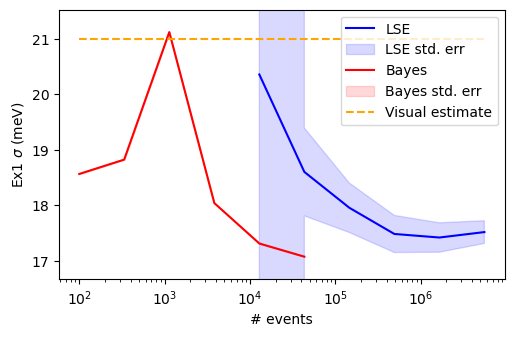

In [42]:
parameter_no = 8
p_conv_plot(parameter_no, param_name='Ex1 $\sigma$ (meV)', savename='arcsFigs/arcs_ex1_sigma.png', correct=21)
#p_conv_plot(parameter_no, LSE=False)

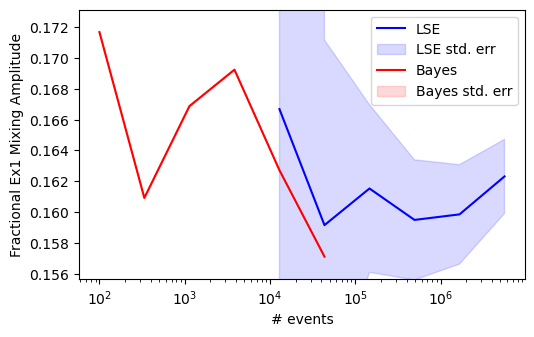

In [43]:
parameter_no = 15
p_conv_plot(parameter_no, param_name='Fractional Ex1 Mixing Amplitude', savename='arcsFigs/arcs_ex1_amplitude.png')
#p_conv_plot(parameter_no, LSE=False)

### Second Excitation Line Parameters

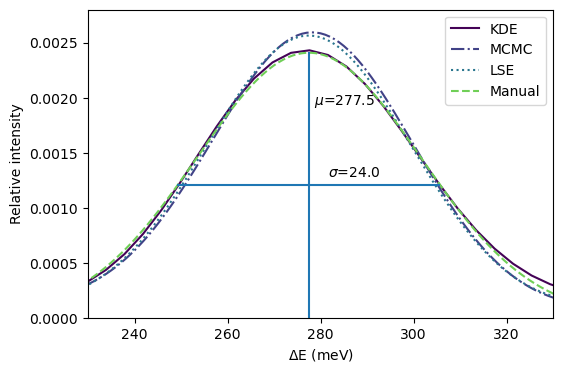

In [44]:
mu=277.5
sig=24.0
normval=6.9
ht=0.00242

r1=230
r2=330

px=np.arange(-200,600,1)
nrm = sp.stats.norm(loc=mu,scale=sig)
py=nrm.pdf(px)/normval

ema1.pmf = probability_mass_function

lstrimp = np.delete(lsparams, 0)

mcmcy = ema1.pmf(mcpparams, px, ema1.xmin, ema1.xmax, None)
lsey = ema1.pmf(lstrimp, px, ema1.xmin, ema1.xmax, None)

mcmc_sum = np.sum(mcmcy)
mcmc_size = mcmcy.size

lsey_sum = np.sum(lsey)
lsey_size = lsey.size

py_sum = np.sum(py)
py_size = py.size

kde_sum = np.sum(ema1.kdey)
kde_size = ema1.kdey.size

hist_sum = np.sum(ema1.histy)
hist_size = ema1.histy.size

sub_hist_sum = np.sum(subsample_histo_y)
sub_hist_size = subsample_histo_y.size

# Check everything is normalised to KDE line, maybe it's already done upstream...

sub_hist_scale = (kde_sum / sub_hist_sum) * (sub_hist_size / kde_size)
hist_scale = (kde_sum / hist_sum) * (hist_size / kde_size)
lsey_scale = (kde_sum / lsey_sum) * (lsey_size / kde_size)
mcmc_scale = (kde_sum / mcmc_sum) * (mcmc_size / kde_size)



fig,ax=plt.subplots()
#plt.plot(ema1.kdex, ema1.kdey)
#plt.plot(px, py, ls='--')
plt.plot(ema1.kdex, ema1.kdey, label='KDE', color=colors[1])
plt.plot(px, mcmcy * mcmc_scale, ls='-.',label='MCMC', color=colors[50])
plt.plot(px, lsey * lsey_scale, ls=':', label='LSE', color=colors[100])
plt.plot(px, py, ls='--', label='Manual', color=colors[200])

plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.vlines(mu, 0.0, ht)
plt.hlines(ht/2.0, mu-2.355*sig/2.0, mu+2.355*sig/2.0)
ax.text(mu+1, ht*0.8, "$\mu$=" + str(mu))
ax.text(mu+4, ht*0.53, "$\sigma$=" + str(sig))
fig.set_size_inches(6,4)
plt.xlim([r1,r2])
plt.ylim([0.0, 0.0028])
plt.legend()
plt.savefig('arcsFigs/arcs_fulldata_kde_ex2.png', dpi=600, bbox_inches='tight')
plt.show()

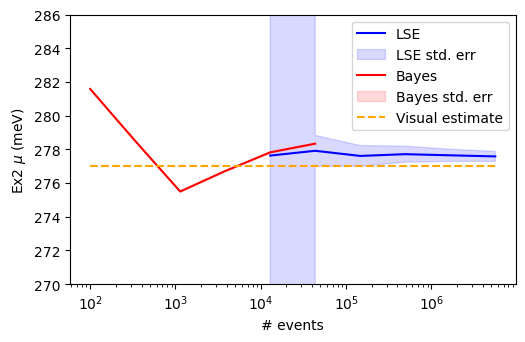

In [45]:
parameter_no = 2
p_conv_plot(parameter_no, param_name='Ex2 $\mu$ (meV)', savename='arcsFigs/arcs_ex2_mu.png', correct=277.0, ylims=[270, 286])
#p_conv_plot(parameter_no, LSE=False)

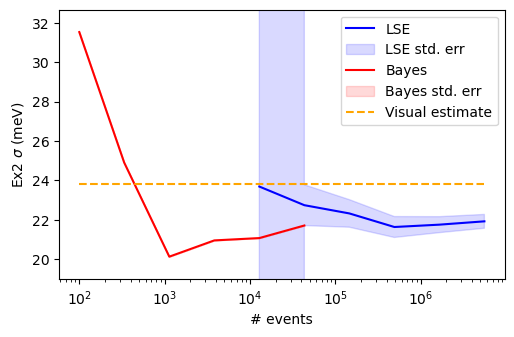

In [46]:
parameter_no = 9
p_conv_plot(parameter_no, param_name='Ex2 $\sigma$ (meV)', savename='arcsFigs/arcs_ex2_sigma.png', correct=23.8)
#p_conv_plot(parameter_no, LSE=False)

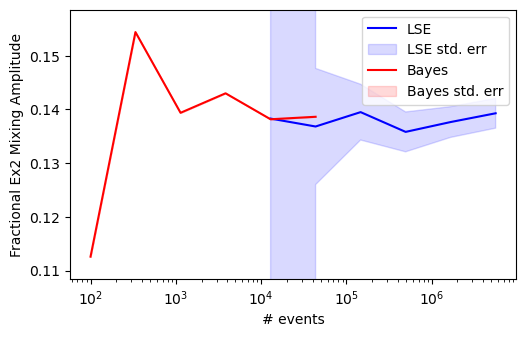

In [47]:
parameter_no = 16
p_conv_plot(parameter_no, param_name='Fractional Ex2 Mixing Amplitude', savename='arcsFigs/arcs_ex2_amplitude.png')
#p_conv_plot(parameter_no, LSE=False)

### Third Excitation Line Parameters

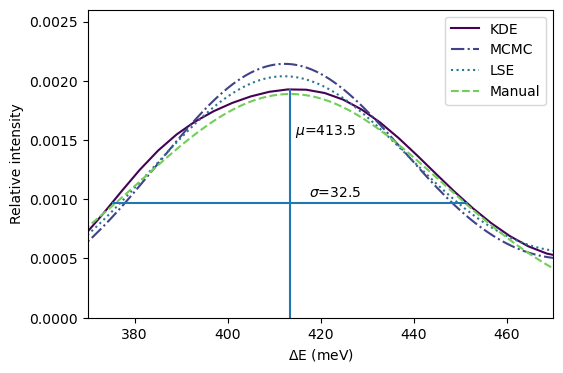

In [48]:
window_mu=420.0
mu=413.5
sig=32.5
normval=6.5
ht=0.00193

r1=window_mu-50
r2=window_mu+50

px=np.arange(-200,600,1)
nrm = sp.stats.norm(loc=mu,scale=sig)
py=nrm.pdf(px)/normval

ema1.pmf = probability_mass_function

lstrimp = np.delete(lsparams, 0)

mcmcy = ema1.pmf(mcpparams, px, ema1.xmin, ema1.xmax, None)
lsey = ema1.pmf(lstrimp, px, ema1.xmin, ema1.xmax, None)

mcmc_sum = np.sum(mcmcy)
mcmc_size = mcmcy.size

lsey_sum = np.sum(lsey)
lsey_size = lsey.size

py_sum = np.sum(py)
py_size = py.size

kde_sum = np.sum(ema1.kdey)
kde_size = ema1.kdey.size

hist_sum = np.sum(ema1.histy)
hist_size = ema1.histy.size

sub_hist_sum = np.sum(subsample_histo_y)
sub_hist_size = subsample_histo_y.size

# Check everything is normalised to KDE line, maybe it's already done upstream...

sub_hist_scale = (kde_sum / sub_hist_sum) * (sub_hist_size / kde_size)
hist_scale = (kde_sum / hist_sum) * (hist_size / kde_size)
lsey_scale = (kde_sum / lsey_sum) * (lsey_size / kde_size)
mcmc_scale = (kde_sum / mcmc_sum) * (mcmc_size / kde_size)


fig,ax=plt.subplots()
#plt.plot(ema1.kdex, ema1.kdey)
#plt.plot(px, py, ls='--')
plt.plot(ema1.kdex, ema1.kdey, label='KDE', color=colors[1])
plt.plot(px, mcmcy * mcmc_scale, ls='-.',label='MCMC', color=colors[50])
plt.plot(px, lsey * lsey_scale, ls=':', label='LSE', color=colors[100])
plt.plot(px, py, ls='--', label='Manual', color=colors[200])

plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.vlines(mu, 0.0, ht)
plt.hlines(ht/2.0, mu-2.355*sig/2.0, mu+2.355*sig/2.0)
ax.text(mu+1, ht*0.8, "$\mu$=" + str(mu))
ax.text(mu+4, ht*0.53, "$\sigma$=" + str(sig))
fig.set_size_inches(6,4)
plt.xlim([r1,r2])
plt.ylim([0.0, 0.0026])
plt.legend()
plt.savefig('arcsFigs/arcs_fulldata_kde_ex3.png', dpi=600, bbox_inches='tight')
plt.show()

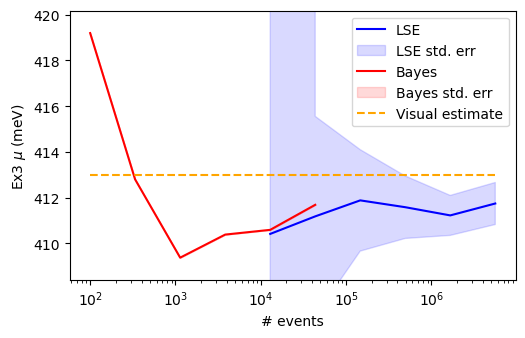

In [49]:
parameter_no = 3
p_conv_plot(parameter_no, param_name='Ex3 $\mu$ (meV)', savename='arcsFigs/arcs_ex3_mu.png', correct=413.0)
#p_conv_plot(parameter_no, LSE=False)

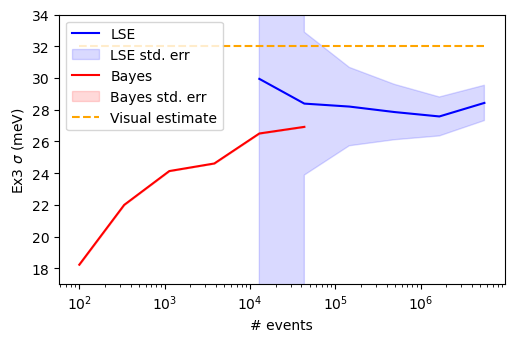

In [50]:
parameter_no = 10
p_conv_plot(parameter_no, param_name='Ex3 $\sigma$ (meV)', savename='arcsFigs/arcs_ex3_sigma.png', correct=32.0, ylims=[17, 34])
#p_conv_plot(parameter_no, LSE=False)

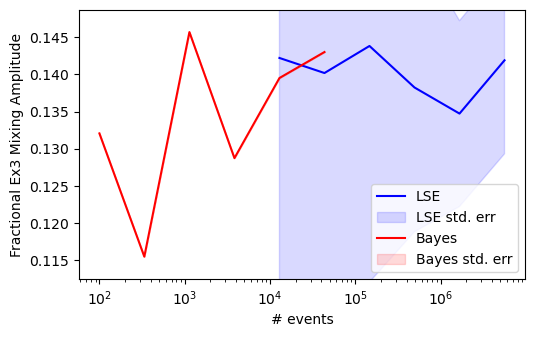

In [51]:
parameter_no = 17
p_conv_plot(parameter_no, param_name='Fractional Ex3 Mixing Amplitude', savename='arcsFigs/arcs_ex3_amplitude.png')
#p_conv_plot(parameter_no, LSE=False)

### Fourth Excitation Line Parameters

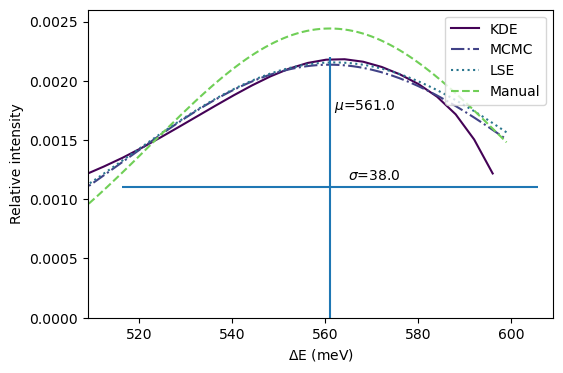

In [52]:
window_mu=559.0
mu=window_mu+2
sig=38.0
normval=4.3
ht=0.0022

r1=window_mu-50
r2=window_mu+50

px=np.arange(-200,600,1)
nrm = sp.stats.norm(loc=mu,scale=sig)
py=nrm.pdf(px)/normval

ema1.pmf = probability_mass_function

lstrimp = np.delete(lsparams, 0)

mcmcy = ema1.pmf(mcpparams, px, ema1.xmin, ema1.xmax, None)
lsey = ema1.pmf(lstrimp, px, ema1.xmin, ema1.xmax, None)

mcmc_sum = np.sum(mcmcy)
mcmc_size = mcmcy.size

lsey_sum = np.sum(lsey)
lsey_size = lsey.size

py_sum = np.sum(py)
py_size = py.size

kde_sum = np.sum(ema1.kdey)
kde_size = ema1.kdey.size

hist_sum = np.sum(ema1.histy)
hist_size = ema1.histy.size

sub_hist_sum = np.sum(subsample_histo_y)
sub_hist_size = subsample_histo_y.size

# Check everything is normalised to KDE line, maybe it's already done upstream...

sub_hist_scale = (kde_sum / sub_hist_sum) * (sub_hist_size / kde_size)
hist_scale = (kde_sum / hist_sum) * (hist_size / kde_size)
lsey_scale = (kde_sum / lsey_sum) * (lsey_size / kde_size)
mcmc_scale = (kde_sum / mcmc_sum) * (mcmc_size / kde_size)



fig,ax=plt.subplots()
#plt.plot(ema1.kdex, ema1.kdey)
#plt.plot(px, py, ls='--')
plt.plot(ema1.kdex, ema1.kdey, label='KDE', color=colors[1])
plt.plot(px, mcmcy * mcmc_scale, ls='-.',label='MCMC', color=colors[50])
plt.plot(px, lsey * lsey_scale, ls=':', label='LSE', color=colors[100])
plt.plot(px, py, ls='--', label='Manual', color=colors[200])


plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.vlines(mu, 0.0, ht)
plt.hlines(ht/2.0, mu-2.355*sig/2.0, mu+2.355*sig/2.0)
ax.text(mu+1, ht*0.8, "$\mu$=" + str(mu))
ax.text(mu+4, ht*0.53, "$\sigma$=" + str(sig))
fig.set_size_inches(6,4)
plt.xlim([r1,r2])
plt.ylim([0.0, 0.0026])
plt.legend(loc='upper right')
plt.savefig('arcsFigs/arcs_fulldata_kde_ex4.png', dpi=600, bbox_inches='tight')
plt.show()

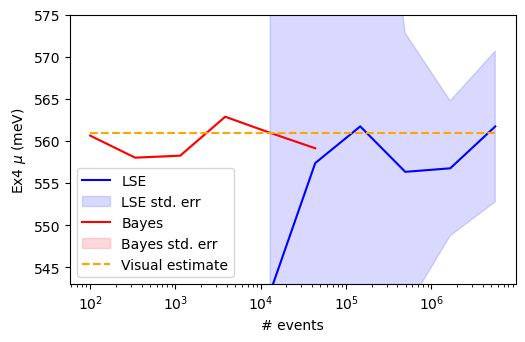

In [53]:
parameter_no = 4
p_conv_plot(parameter_no, param_name='Ex4 $\mu$ (meV)', savename='arcsFigs/arcs_ex4_mu.png', correct=mu, ylims=[543, 575])
#p_conv_plot(parameter_no, LSE=False)

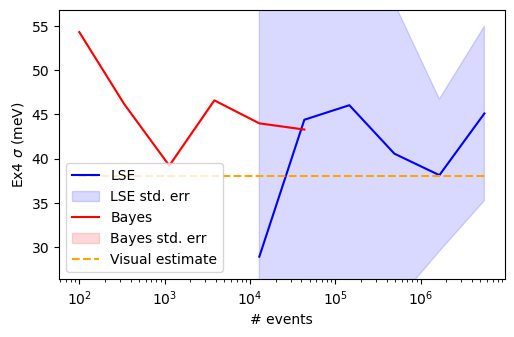

In [54]:
parameter_no = 11
p_conv_plot(parameter_no, param_name='Ex4 $\sigma$ (meV)', savename='arcsFigs/arcs_ex4_sigma.png', correct=sig)
#p_conv_plot(parameter_no, LSE=False)

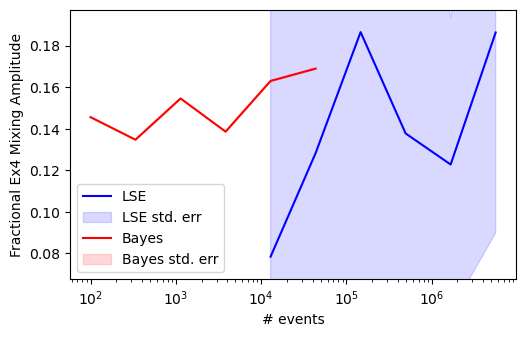

In [55]:
parameter_no = 18
p_conv_plot(parameter_no, param_name='Fractional Ex4 Mixing Amplitude', savename='arcsFigs/arcs_ex4_amplitude.png')
#p_conv_plot(parameter_no, LSE=False)

### First Background Term Parameters 

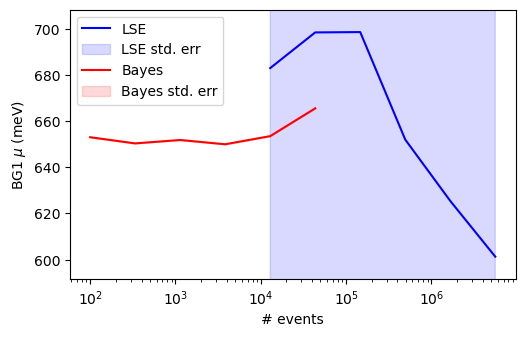

In [56]:
parameter_no = 5
p_conv_plot(parameter_no, param_name='BG1 $\mu$ (meV)', savename='arcsFigs/arcs_BG1_mu.png')
#p_conv_plot(parameter_no, LSE=False)

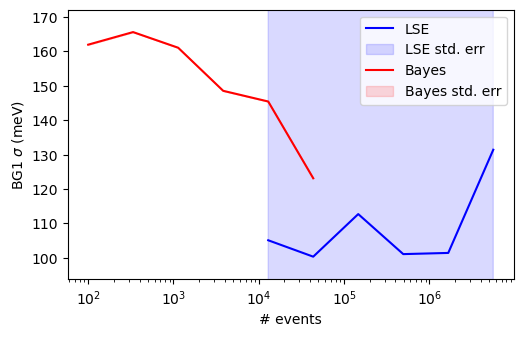

In [57]:
parameter_no = 12
p_conv_plot(parameter_no, param_name='BG1 $\sigma$ (meV)', savename='arcsFigs/arcs_BG1_sigma.png')
#p_conv_plot(parameter_no, LSE=False)

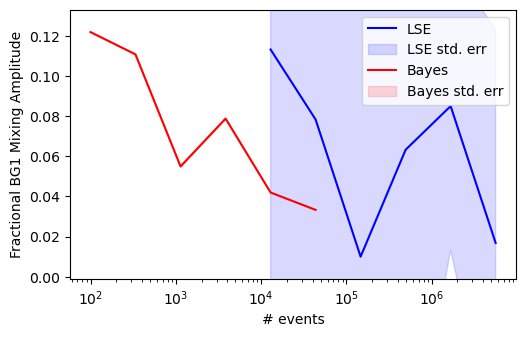

In [58]:
parameter_no = 19
p_conv_plot(parameter_no, param_name='Fractional BG1 Mixing Amplitude', savename='arcsFigs/arcs_BG1_amplitude.png')
#p_conv_plot(parameter_no, LSE=False)

### Second Background Term Parameters

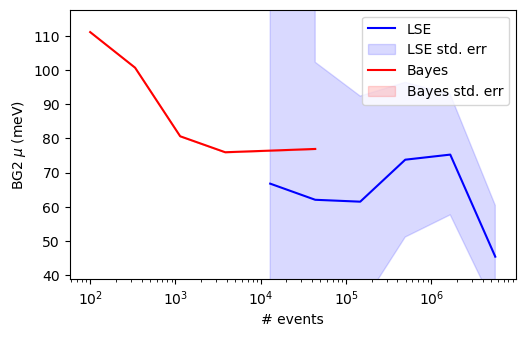

In [59]:
parameter_no = 6
p_conv_plot(parameter_no, param_name='BG2 $\mu$ (meV)', savename='arcsFigs/arcs_BG2_mu.png')
#p_conv_plot(parameter_no, LSE=False)

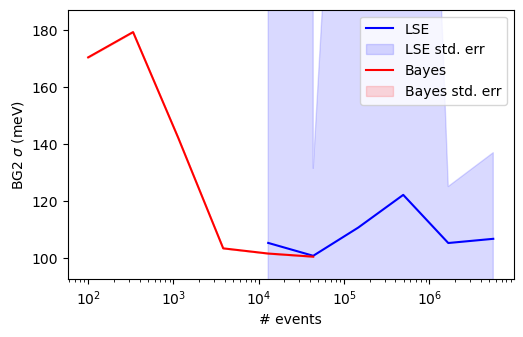

In [60]:
parameter_no = 13
p_conv_plot(parameter_no, param_name='BG2 $\sigma$ (meV)', savename='arcsFigs/arcs_BG2_sigma.png')
#p_conv_plot(parameter_no, LSE=False)

The weight of the second background term is computed from 1-sum(other_weights) so it has no individual parameter.

## Important Questions and Possible Answers

1. Why does the parameter noise obviously exceed the reported variance for the MCMC parameters?

Probably because the random subsample of events is at each step random.  The variance is the *statistical* variance as sampled by MCMC within the data set, whilst the subsampling of the events for low numbers of events provides a systematic shift of that parameter space from analysis to analysis.  The correct variance would probably be obtained by re-subsampling many times and computing the mean and standard error of the obtained parameters.  This is going to be very slow and would require a cluster job in the future to do that work.

2. Why does the variance on some LSE parameters increase with increasing events?

Probably because the LSE is unstable with so many parameters, and it is getting stuck in a local optimum.  If you look at some of the parameters the stated variances for these parameters are enormous, so the LSE estimates from the chi-squared surface curvature are probably wrong.  Since many of the parameter values are so close to those obtained from MCMC I suspect that monte-carlo sampling the LSE parameter space as described above might yield more realistic parameter variances.
